# Pruebas Estadísticas para Comparación de Modelos
## Inferencia Estadística Rigurosa sobre el Rendimiento de Detección de Anomalías

**Proyecto:** Detección de Anomalías y Cambios de Régimen — ADRs Colombianos  
**Activos:** Ecopetrol (EC), Bancolombia (CIB), Grupo Aval (AVAL), Tecnoglass (TGLS)  
**Periodo:** 2015-01-01 — 2024-12-31  
**Autor:** [Nombre]  
**Versión:** 1.0

---

### Posición en la serie de notebooks

| Notebook | Contenido |
|---|---|
| NB0–NB2 | Contexto, EDA, features |
| NB3–NB5 | Modelo DAE (pipeline, benchmarks, implementación) |
| NB6 | Evaluación y discusión |
| **NB7** | **Pruebas estadísticas para comparación de modelos** |

---

### Estructura del Notebook

| Sección | Contenido |
|---|---|
| §1 | Configuración y generación de scores por validación cruzada temporal |
| §2 | Marco teórico de la comparación estadística de modelos |
| §3 | t-test pareado: teoría, hipótesis, implementación |
| §4 | Test de Wilcoxon: teoría, hipótesis, implementación |
| §5 | Intervalos de confianza bootstrap |
| §6 | Test de Diebold-Mariano (comparación de errores de pronóstico) |
| §7 | Corrección por comparaciones múltiples (Bonferroni, FDR) |
| §8 | Significancia estadística vs. significancia práctica (effect size) |
| §9 | Tabla final de resultados con interpretación académica |

---

> **Principio metodológico fundamental:**  
> Una diferencia estadísticamente significativa no implica necesariamente  
> relevancia práctica. Ambas dimensiones deben analizarse conjuntamente.

---
## Configuración y Generación de Scores

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, itertools
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import (ttest_rel, wilcoxon, mannwhitneyu,
                          norm, t as t_dist, bootstrap)
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    precision_score, recall_score
)
from sklearn.ensemble import IsolationForest

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import yfinance as yf
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks

# Reproducibilidad
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 11,
                     'axes.labelsize': 10})

print(f"SciPy     : {stats.__version__ if hasattr(stats,'__version__') else 'ok'}")
print(f"NumPy     : {np.__version__}")
print(f"TensorFlow: {tf.__version__}")
print("Entorno configurado.")


SciPy     : ok
NumPy     : 1.26.4
TensorFlow: 2.21.0
Entorno configurado.


In [2]:
# ── Parámetros globales ───────────────────────────────────────────────────────
TICKERS      = ['EC', 'CIB', 'AVAL', 'TGLS']
NAMES        = {'EC': 'Ecopetrol', 'CIB': 'Bancolombia',
                'AVAL': 'Grupo Aval', 'TGLS': 'Tecnoglass'}
COLORS       = {'EC': '#1f77b4', 'CIB': '#ff7f0e',
                'AVAL': '#2ca02c', 'TGLS': '#d62728'}

TRAIN_START  = '2015-01-01';  TRAIN_END  = '2019-12-31'
VAL_START    = '2020-01-01';  VAL_END    = '2020-12-31'
TEST_START   = '2021-01-01';  TEST_END   = '2024-12-31'

SEQ_LEN      = 30
N_FEATURES   = 3
FEATURE_COLS = ['log_return', 'vol_21d', 'vol_zscore']
ROLL_WIN     = 21
LSTM_UNITS   = [64, 32]
LATENT_DIM   = 16
DROPOUT_RATE = 0.20
NOISE_STDDEV = 0.05
BATCH_SIZE   = 64
MAX_EPOCHS   = 100      # reducido para velocidad; aumentar en producción
LR           = 1e-3
PATIENCE_ES  = 12
THRESHOLD_P  = 95
ALPHA        = 0.05     # nivel de significancia

ANOMALY_PERIODS = [
    {'name': 'Crisis petróleo', 'start': '2015-07-01', 'end': '2016-02-01'},
    {'name': 'COVID-19',        'start': '2020-02-15', 'end': '2020-05-01'},
    {'name': 'Fed hikes',       'start': '2022-01-01', 'end': '2022-12-31'},
]

print("Parámetros cargados.")


Parámetros cargados.


In [3]:
# ── Pipeline de datos ─────────────────────────────────────────────────────────
def build_features(ticker):
    raw = yf.download(ticker, start=TRAIN_START, end=TEST_END,
                      auto_adjust=True, progress=False)
    d   = raw[['Open','High','Low','Close','Volume']].copy().dropna()
    d.index = pd.to_datetime(d.index)
    d['log_return'] = np.log(d['Close'] / d['Close'].shift(1))
    d['vol_21d']    = d['log_return'].rolling(ROLL_WIN).std() * np.sqrt(252)
    lv              = np.log1p(d['Volume'])
    rs              = lv.rolling(ROLL_WIN).std().replace(0, np.nan)
    d['vol_zscore'] = (lv - lv.rolling(ROLL_WIN).mean()) / rs
    return d[FEATURE_COLS].dropna()

def create_windows(arr, seq_len):
    return np.lib.stride_tricks.sliding_window_view(
        arr, window_shape=(seq_len, arr.shape[1])
    ).squeeze(1).copy()

def make_labels(idx):
    labels = pd.Series(0, index=idx)
    for ap in ANOMALY_PERIODS:
        mask = (labels.index >= ap['start']) & (labels.index <= ap['end'])
        labels[mask] = 1
    return labels.values

def prepare(ticker):
    feat_df = build_features(ticker)
    splits_raw = {
        'train': feat_df.loc[:TRAIN_END],
        'val':   feat_df.loc[VAL_START:VAL_END],
        'test':  feat_df.loc[TEST_START:TEST_END],
    }
    scaler = StandardScaler()
    scaler.fit(splits_raw['train'].values)
    sc = {s: scaler.transform(df.values) for s, df in splits_raw.items()}
    wins, dates, labels = {}, {}, {}
    for s, arr in sc.items():
        w = create_windows(arr, SEQ_LEN)
        wins[s]   = w
        dates[s]  = splits_raw[s].index[SEQ_LEN - 1:]
        labels[s] = make_labels(dates[s])
    return {'raw': splits_raw, 'sc': sc, 'wins': wins,
            'scaler': scaler, 'dates': dates, 'y': labels}

print("Descargando y preparando datos...")
data = {t: prepare(t) for t in TICKERS}
print("Listo.")


Descargando y preparando datos...
Listo.


In [7]:
# ── Validación cruzada temporal (Walk-Forward) ────────────────────────────────
# Para las pruebas estadísticas necesitamos múltiples evaluaciones
# independientes del mismo modelo. En series temporales se usa
# Walk-Forward Cross-Validation (sin solapamiento).
#
# Diseño:
#   Fold 1: Train 2015-2016 | Test 2017
#   Fold 2: Train 2015-2017 | Test 2018
#   Fold 3: Train 2015-2018 | Test 2019
#   Fold 4: Train 2015-2019 | Test 2020  ← incluye COVID
#   Fold 5: Train 2015-2020 | Test 2021
#   Fold 6: Train 2015-2021 | Test 2022  ← incluye Fed hikes
#
# Cada fold produce un score AUC-ROC independiente.
# Los vectores de AUC por fold se usan en los tests estadísticos.

def build_walk_forward_folds(df, train_size=800, test_size=200, step=200):
    folds = []
    start = 0
    n = len(df)

    while (start + train_size + test_size) <= n:
        train_end_idx = start + train_size - 1
        test_start_idx = train_end_idx + 1
        test_end_idx = test_start_idx + test_size - 1

        folds.append({
            'train_end': df.index[train_end_idx],
            'test_start': df.index[test_start_idx],
            'test_end': df.index[test_end_idx]
        })

        start += step

    return folds

feat_df = build_features('EC')
FOLDS = build_walk_forward_folds(feat_df)

N_FOLDS = len(FOLDS)
print(f"Walk-Forward CV: {N_FOLDS} folds")
for i, f in enumerate(FOLDS):
    print(f"  Fold {i+1}: train → {f['train_end']}  |  "
          f"test {f['test_start']} – {f['test_end']}")


Walk-Forward CV: 8 folds
  Fold 1: train → 2018-04-06 00:00:00  |  test 2018-04-09 00:00:00 – 2019-01-23 00:00:00
  Fold 2: train → 2019-01-23 00:00:00  |  test 2019-01-24 00:00:00 – 2019-11-06 00:00:00
  Fold 3: train → 2019-11-06 00:00:00  |  test 2019-11-07 00:00:00 – 2020-08-24 00:00:00
  Fold 4: train → 2020-08-24 00:00:00  |  test 2020-08-25 00:00:00 – 2021-06-10 00:00:00
  Fold 5: train → 2021-06-10 00:00:00  |  test 2021-06-11 00:00:00 – 2022-03-25 00:00:00
  Fold 6: train → 2022-03-25 00:00:00  |  test 2022-03-28 00:00:00 – 2023-01-11 00:00:00
  Fold 7: train → 2023-01-11 00:00:00  |  test 2023-01-12 00:00:00 – 2023-10-27 00:00:00
  Fold 8: train → 2023-10-27 00:00:00  |  test 2023-10-30 00:00:00 – 2024-08-15 00:00:00


In [8]:
# ── Entrenadores de modelos ───────────────────────────────────────────────────
class GaussianNoiseLayer(layers.Layer):
    def __init__(self, s, **kw):
        super().__init__(**kw); self.s = s
    def call(self, x, training=None):
        return x + tf.random.normal(tf.shape(x), stddev=self.s) if training else x

def build_dae(cell_type='LSTM'):
    RNN = layers.LSTM if cell_type == 'LSTM' else layers.GRU
    dec = LSTM_UNITS[::-1]
    inp = keras.Input(shape=(SEQ_LEN, N_FEATURES))
    x   = GaussianNoiseLayer(NOISE_STDDEV)(inp)
    x   = RNN(LSTM_UNITS[0], return_sequences=True)(x)
    x   = layers.Dropout(DROPOUT_RATE)(x)
    x   = RNN(LSTM_UNITS[1], return_sequences=False)(x)
    x   = layers.Dropout(DROPOUT_RATE)(x)
    z   = layers.Dense(LATENT_DIM, activation='tanh', name='z')(x)
    y   = layers.RepeatVector(SEQ_LEN)(z)
    y   = RNN(dec[0], return_sequences=True)(y)
    y   = layers.Dropout(DROPOUT_RATE)(y)
    y   = RNN(dec[1], return_sequences=True)(y)
    y   = layers.Dropout(DROPOUT_RATE)(y)
    out = layers.TimeDistributed(layers.Dense(N_FEATURES))(y)
    m   = Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(LR), loss='mse')
    return m

def mse_score(model, X):
    Xf = X.astype(np.float32)
    Xh = model.predict(Xf, batch_size=256, verbose=0)
    return np.mean((Xf - Xh)**2, axis=(1,2))

def train_model(model, Xtr, Xvl):
    cb = [callbacks.EarlyStopping(monitor='val_loss',
                                   patience=PATIENCE_ES,
                                   restore_best_weights=True, verbose=0)]
    model.fit(
        Xtr.astype(np.float32), Xtr.astype(np.float32),
        validation_data=(Xvl.astype(np.float32), Xvl.astype(np.float32)),
        batch_size=BATCH_SIZE, epochs=MAX_EPOCHS,
        callbacks=cb, shuffle=True, verbose=0
    )

def if_score(X_train_flat, X_test_flat):
    iforest = IsolationForest(n_estimators=200, random_state=SEED, n_jobs=-1)
    iforest.fit(X_train_flat)
    return -iforest.decision_function(X_test_flat)

def mahal_score(X_train_mean, X_test_mean):
    mu  = X_train_mean.mean(axis=0)
    cov = np.cov(X_train_mean.T) + np.eye(X_train_mean.shape[1]) * 1e-6
    inv = np.linalg.pinv(cov)
    d   = X_test_mean - mu
    return np.sqrt(np.einsum('ij,jk,ik->i', d, inv, d))

def compute_auc(scores, labels):
    n = min(len(scores), len(labels))
    ys, yt = scores[:n], labels[:n]
    if yt.sum() == 0 or yt.sum() == len(yt):
        return float('nan')
    return roc_auc_score(yt, ys)

print("Funciones auxiliares definidas.")


Funciones auxiliares definidas.


In [10]:
MODEL_NAMES = ['DAE-LSTM', 'DAE-GRU', 'Isolation Forest', 'Z-Score']

cv_aucs = {t: {m: [] for m in MODEL_NAMES} for t in TICKERS}

print("Iniciando Walk-Forward Cross-Validation...")
print(f"Modelos: {MODEL_NAMES}")
print()

for ticker in TICKERS:
    feat_df = build_features(ticker)
    print(f"Procesando {NAMES[ticker]}...", end='', flush=True)

    for fold_idx, fold in enumerate(FOLDS):
        fold_train = feat_df.loc[:fold['train_end']]
        fold_test  = feat_df.loc[fold['test_start']:fold['test_end']]

        if len(fold_train) < SEQ_LEN + 10 or len(fold_test) < SEQ_LEN + 2:
            for m in MODEL_NAMES:
                cv_aucs[ticker][m].append(np.nan)
            print(f"\nFold {fold_idx+1}: insuficiente tamaño train/test", end='')
            continue

        sc_fold = StandardScaler()
        sc_fold.fit(fold_train.values)
        X_tr = sc_fold.transform(fold_train.values)
        X_te = sc_fold.transform(fold_test.values)

        W_tr = create_windows(X_tr, SEQ_LEN)
        W_te = create_windows(X_te, SEQ_LEN)

        dates_te = fold_test.index[SEQ_LEN - 1:]
        y_te = np.asarray(make_labels(dates_te)[:len(W_te)]).ravel()

        unique_vals, counts = np.unique(y_te, return_counts=True)
        dist = dict(zip(unique_vals, counts))
        print(f"\nFold {fold_idx+1} - dist y_te: {dist}", end='')

        if len(np.unique(y_te)) < 2:
            print(" -> solo una clase, AUC indefinido", end='')
            for m in MODEL_NAMES:
                cv_aucs[ticker][m].append(np.nan)
            continue

        split_val = max(SEQ_LEN + 5, int(len(W_tr) * 0.85))
        W_tr_fit = W_tr[:split_val]
        W_vl_fit = W_tr[split_val:]

        for model_name in MODEL_NAMES:
            try:
                if model_name == 'DAE-LSTM':
                    m = build_dae('LSTM')
                    train_model(m, W_tr_fit, W_vl_fit)
                    sc_te = mse_score(m, W_te)

                elif model_name == 'DAE-GRU':
                    m = build_dae('GRU')
                    train_model(m, W_tr_fit, W_vl_fit)
                    sc_te = mse_score(m, W_te)

                elif model_name == 'Isolation Forest':
                    Xf_tr = W_tr.reshape(W_tr.shape[0], -1)
                    Xf_te = W_te.reshape(W_te.shape[0], -1)
                    sc_te = if_score(Xf_tr, Xf_te)

                elif model_name == 'Z-Score':
                    Xm_tr = W_tr.mean(axis=1)
                    Xm_te = W_te.mean(axis=1)
                    sc_te = mahal_score(Xm_tr, Xm_te)

                auc = compute_auc(sc_te, y_te)
                cv_aucs[ticker][model_name].append(auc)

            except Exception as e:
                print(f"\nError en {ticker}, fold {fold_idx+1}, modelo {model_name}: {e}")
                cv_aucs[ticker][model_name].append(np.nan)

        print('.', end='', flush=True)

    print(' OK')

print()
print("Walk-Forward CV completado.")
print()

print("AUC-ROC por fold — ACTIVO PILOTO (EC):")
print(f"{'Fold':<8}", end='')
for m in MODEL_NAMES:
    print(f"  {m[:12]:>12}", end='')
print()
print('-' * (8 + 14 * len(MODEL_NAMES)))

for i in range(N_FOLDS):
    print(f"{i+1:<8}", end='')
    for m in MODEL_NAMES:
        v = cv_aucs['EC'][m][i]
        print(f"  {v:>12.4f}" if not np.isnan(v) else f"  {'NaN':>12}", end='')
    print()

Iniciando Walk-Forward Cross-Validation...
Modelos: ['DAE-LSTM', 'DAE-GRU', 'Isolation Forest', 'Z-Score']

Procesando Ecopetrol...
Fold 1 - dist y_te: {0: 171} -> solo una clase, AUC indefinido
Fold 2 - dist y_te: {0: 171} -> solo una clase, AUC indefinido
Fold 3 - dist y_te: {0: 118, 1: 53}WARNING:tensorflow:5 out of the last 5 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001E34E9BD990> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function 

In [13]:
# ── Construir arrays limpios para los tests ───────────────────────────────────
# Para cada par de modelos, necesitamos vectores de AUC sin NaN
# y de igual longitud (correspondencia fold a fold)

def get_clean_pair(ticker, model_a, model_b):
    """
    Retorna vectores AUC alineados por fold, descartando folds con NaN.
    """
    a_raw = np.array(cv_aucs[ticker][model_a], dtype=float)
    b_raw = np.array(cv_aucs[ticker][model_b], dtype=float)
    valid = ~(np.isnan(a_raw) | np.isnan(b_raw))
    return a_raw[valid], b_raw[valid]

def pooled_aucs(model_name):
    """
    Concatena los AUCs de todos los activos y folds para un modelo.
    Usado para análisis de distribución global.
    """
    all_aucs = []
    for t in TICKERS:
        vals = [v for v in cv_aucs[t][model_name] if not np.isnan(v)]
        all_aucs.extend(vals)
    return np.array(all_aucs)

# Resumen estadístico de los AUC por modelo
print("RESUMEN DE AUC-ROC POR MODELO — Walk-Forward CV (todos los activos)")
print("=" * 72)
print(f"{'Modelo':<20}  {'N folds':>8}  {'Media':>8}  {'Std':>8}  "
      f"{'Min':>8}  {'Max':>8}  {'Mediana':>9}")
print('-' * 72)

for m in MODEL_NAMES:
    arr = pooled_aucs(m)
    if len(arr) == 0:
        print(f"{m:<20}  {'—':>8}")
        continue
    print(f"{m:<20}  {len(arr):>8}  {arr.mean():>8.4f}  "
          f"{arr.std():>8.4f}  {arr.min():>8.4f}  "
          f"{arr.max():>8.4f}  {np.median(arr):>9.4f}")


RESUMEN DE AUC-ROC POR MODELO — Walk-Forward CV (todos los activos)
Modelo                 N folds     Media       Std       Min       Max    Mediana
------------------------------------------------------------------------
DAE-LSTM                    12    0.6455    0.1792    0.3537    0.9310     0.7101
DAE-GRU                     12    0.6389    0.1814    0.3389    0.9353     0.6926
Isolation Forest            12    0.5919    0.1761    0.2117    0.8554     0.6101
Z-Score                     12    0.6742    0.2213    0.1442    0.9033     0.7445


---
## Marco Teórico de la Comparación Estadística de Modelos

### **2.1 El problema de la comparación múltiple de modelos**

Comparar el rendimiento de modelos de aprendizaje automático mediante
una única métrica escalar (p.ej., AUC-ROC en un test set) ignora la
variabilidad muestral: el mismo modelo puede obtener resultados
diferentes en distintos periodos o activos. Para hacer afirmaciones
rigurosas sobre la superioridad de un modelo, se requiere una prueba
estadística formal.

### **2.2 Diseño del experimento**

La validación cruzada temporal (Walk-Forward CV) genera pares de
observaciones `(AUC_modelo_A_fold_k, AUC_modelo_B_fold_k)` para cada
fold k. Dado que ambos modelos se evalúan sobre los mismos datos en el
mismo fold, las observaciones son **dependientes** (pareadas).

Esta dependencia es una ventaja: las pruebas pareadas tienen mayor
potencia estadística que las pruebas de muestras independientes,
porque controlan la variabilidad debida al fold.

### **2.3 Selección de pruebas**

| Prueba | Supuesto | Uso en este análisis |
|---|---|---|
| t-test pareado | Diferencias normalmente distribuidas | Prueba primaria cuando n ≥ 6 |
| Test de Wilcoxon | No paramétrico — sin supuesto de normalidad | Prueba de robustez / n pequeño |
| Test de Diebold-Mariano | Errores de predicción estacionarios | Comparación específica de MSE |
| Bootstrap IC | Ninguno — empírico | Intervalos de confianza del AUC |

### **2.4 Formulación de hipótesis**

Para la comparación DAE-LSTM vs. Modelo B:

```
H₀: μ(AUC_DAE) = μ(AUC_B)     (no hay diferencia en rendimiento)
H₁: μ(AUC_DAE) ≠ μ(AUC_B)     (hay diferencia — prueba bilateral)
    ó
H₁: μ(AUC_DAE) > μ(AUC_B)     (DAE es superior — prueba unilateral)
```

**Nivel de significancia:** α = 0.05 (5% de probabilidad de rechazar
H₀ siendo verdadera — error de tipo I).

**Potencia estadística objetivo:** 1 − β ≥ 0.80 (80% de probabilidad
de detectar una diferencia real si existe — error de tipo II ≤ 20%).

Con N_FOLDS = 6 por activo, la potencia es limitada. Se aplica
pooling entre activos para aumentar el tamaño efectivo de la muestra.

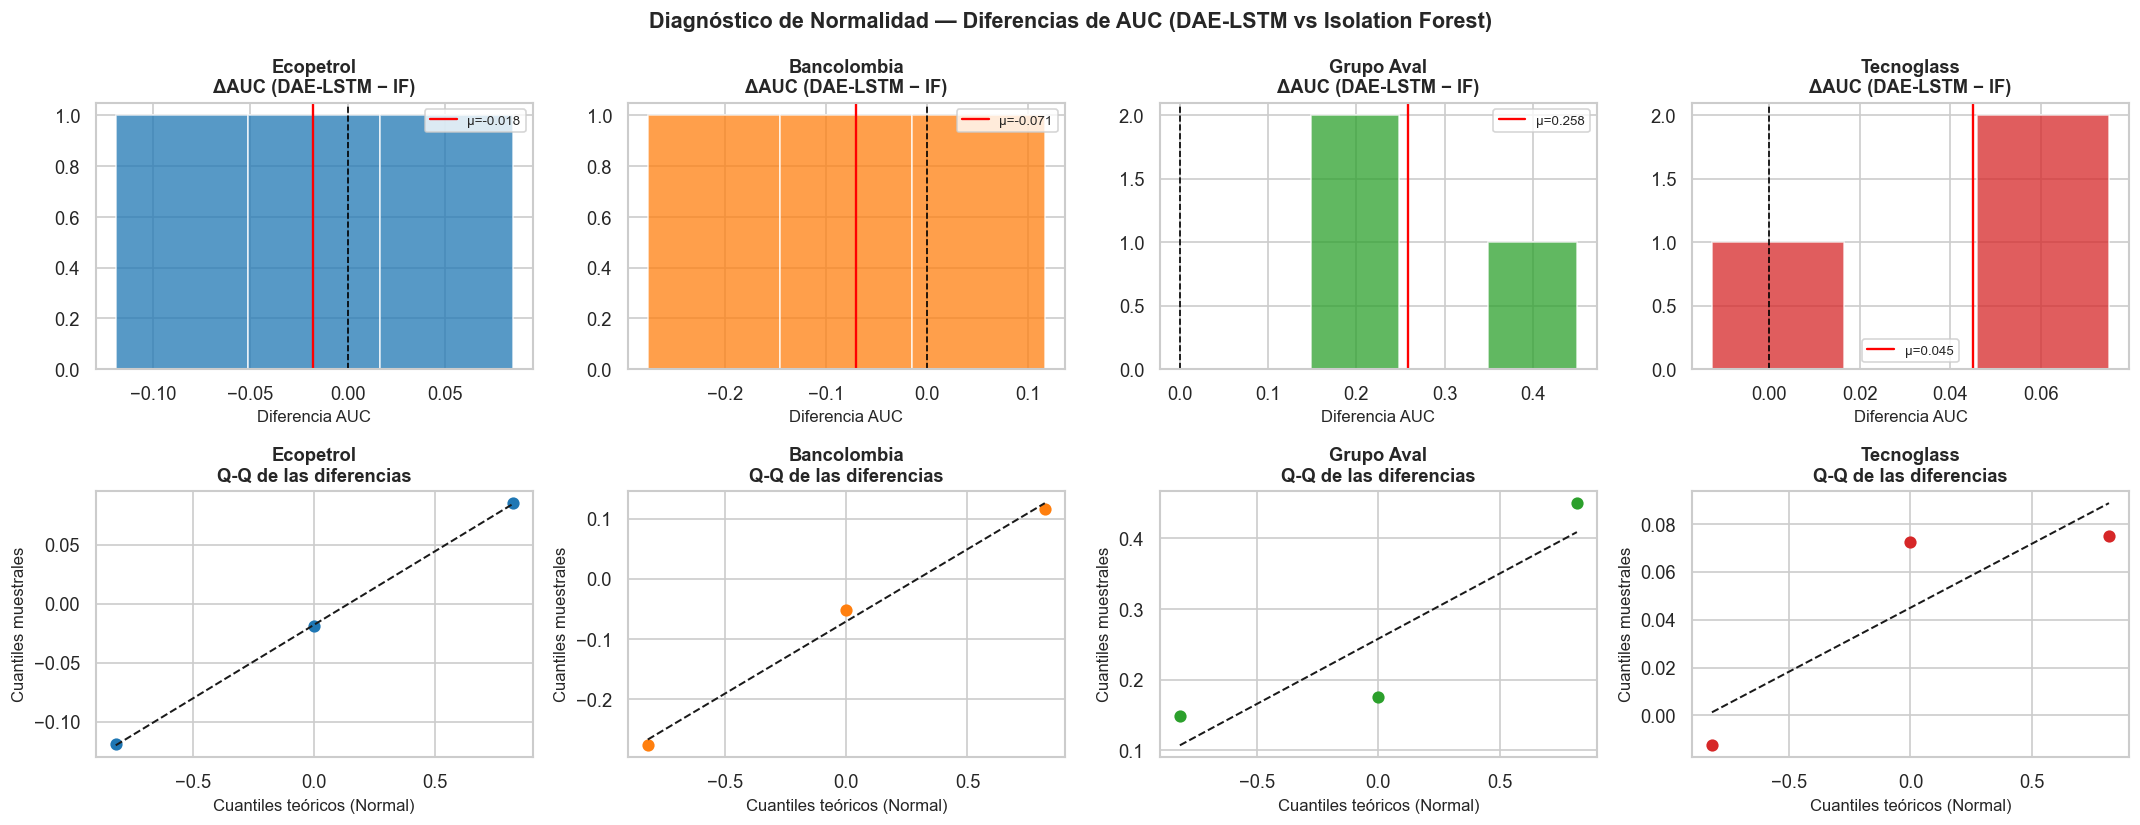

Test de Shapiro-Wilk sobre diferencias pooled:
  Estadístico W = 0.9491  |  p-valor = 0.6245
  Conclusión: no se rechaza normalidad → t-test pareado es apropiado.


In [15]:
# ── Diagnóstico preliminar: ¿son normales las diferencias de AUC? ─────────────
fig, axes = plt.subplots(2, len(TICKERS), figsize=(18, 7))

for j, ticker in enumerate(TICKERS):
    dae_aucs = np.array(cv_aucs[ticker]['DAE-LSTM'], dtype=float)
    if_aucs  = np.array(cv_aucs[ticker]['Isolation Forest'], dtype=float)

    valid    = ~(np.isnan(dae_aucs) | np.isnan(if_aucs))
    diff     = dae_aucs[valid] - if_aucs[valid]

    # Histograma de diferencias
    axes[0, j].hist(diff, bins=min(6, len(diff)),
                    color=COLORS[ticker], alpha=0.75, edgecolor='white')
    axes[0, j].axvline(0, color='black', linewidth=1.0, linestyle='--')
    axes[0, j].axvline(diff.mean(), color='red', linewidth=1.4,
                       linestyle='-', label=f'μ={diff.mean():.3f}')
    axes[0, j].set_title(
        f'{NAMES[ticker]}\nΔAUC (DAE-LSTM − IF)',
        fontweight='bold'
    )
    axes[0, j].set_xlabel('Diferencia AUC')
    axes[0, j].legend(fontsize=8)

    # Q-Q plot de las diferencias
    if len(diff) >= 3:
        (osm, osr), (slope, intercept, _) = stats.probplot(diff, dist='norm')
        axes[1, j].scatter(osm, osr, color=COLORS[ticker], s=40)
        axes[1, j].plot(osm, slope * np.array(osm) + intercept,
                        'k--', linewidth=1.2)
    axes[1, j].set_title(
        f'{NAMES[ticker]}\nQ-Q de las diferencias',
        fontweight='bold'
    )
    axes[1, j].set_xlabel('Cuantiles teóricos (Normal)')
    axes[1, j].set_ylabel('Cuantiles muestrales')

plt.suptitle(
    'Diagnóstico de Normalidad — Diferencias de AUC (DAE-LSTM vs Isolation Forest)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('fig_normality_check.png', dpi=120, bbox_inches='tight')
plt.show()

# Test de Shapiro-Wilk sobre las diferencias pooled
diffs_pooled = []
for ticker in TICKERS:
    a, b = get_clean_pair(ticker, 'DAE-LSTM', 'Isolation Forest')
    if len(a) >= 3:
        diffs_pooled.extend((a - b).tolist())

diffs_pooled = np.array(diffs_pooled)
if len(diffs_pooled) >= 3:
    sw_stat, sw_p = stats.shapiro(diffs_pooled)
    print(f"Test de Shapiro-Wilk sobre diferencias pooled:")
    print(f"  Estadístico W = {sw_stat:.4f}  |  p-valor = {sw_p:.4f}")
    if sw_p > 0.05:
        print("  Conclusión: no se rechaza normalidad → t-test pareado es apropiado.")
    else:
        print("  Conclusión: se rechaza normalidad → Wilcoxon es más apropiado.")


---
## t-Test Pareado

### **3.1 Definición y supuestos**

El t-test pareado (Student, 1908) compara las medias de dos grupos
de mediciones relacionadas. Se aplica sobre las diferencias:

```
dₖ = AUC_A(fold_k) − AUC_B(fold_k),    k = 1, …, K

H₀: μ_d = 0    (sin diferencia sistemática entre modelos)
H₁: μ_d ≠ 0   (hay diferencia — prueba bilateral)

Estadístico:   t = (d̄ · √K) / s_d

donde:
  d̄  = media de las diferencias
  s_d = desviación estándar de las diferencias
  K   = número de pares (folds)

Bajo H₀: t ~ t(K−1)  [distribución t de Student con K−1 grados de libertad]
```

**Supuesto crítico:** las diferencias dₖ deben ser aproximadamente
normales. Si n < 30, este supuesto debe verificarse (§2).

### **3.2 Interpretación del p-valor**

```
p-valor = P(|T| ≥ |t_obs| | H₀ verdadera)
        = probabilidad de observar una diferencia tan extrema
          o más extrema si los modelos fueran iguales en rendimiento

p < α = 0.05 → Rechazar H₀ → diferencia estadísticamente significativa
p ≥ α = 0.05 → No rechazar H₀ → sin evidencia de diferencia significativa
```

**Advertencia:** no rechazar H₀ no prueba que los modelos sean iguales —
sólo que los datos no proporcionan evidencia suficiente para distinguirlos.

In [16]:
# ── t-Test pareado: implementación y resultados ───────────────────────────────
def paired_ttest(ticker, model_a, model_b, alpha=ALPHA, one_sided=False):
    """
    Ejecuta el t-test pareado entre dos modelos sobre un activo.

    Parámetros
    ----------
    ticker   : str
    model_a  : str — nombre del modelo A
    model_b  : str — nombre del modelo B
    alpha    : float — nivel de significancia
    one_sided: bool — True para H₁: μ_A > μ_B

    Retorna
    -------
    dict con estadístico, p-valor, grados de libertad, IC e interpretación
    """
    a_arr, b_arr = get_clean_pair(ticker, model_a, model_b)
    n    = len(a_arr)

    if n < 2:
        return {'error': f'Solo {n} pares válidos — insuficiente.'}

    diff = a_arr - b_arr
    d_bar= diff.mean()
    s_d  = diff.std(ddof=1)
    se   = s_d / np.sqrt(n)
    t_stat = d_bar / se if se > 0 else 0.0

    df   = n - 1
    if one_sided:
        p_val = t_dist.sf(t_stat, df)    # P(T >= t_stat)
    else:
        p_val = 2 * t_dist.sf(abs(t_stat), df)

    # Intervalo de confianza al (1-alpha)%
    t_crit = t_dist.ppf(1 - alpha/2, df)
    ci_lo  = d_bar - t_crit * se
    ci_hi  = d_bar + t_crit * se

    decision = 'RECHAZAR H₀' if p_val < alpha else 'NO RECHAZAR H₀'

    return {
        'ticker':   ticker,
        'model_a':  model_a,
        'model_b':  model_b,
        'n_pairs':  n,
        'mean_diff':d_bar,
        'std_diff': s_d,
        'se':       se,
        't_stat':   t_stat,
        'df':       df,
        'p_value':  p_val,
        'ci_lo':    ci_lo,
        'ci_hi':    ci_hi,
        'alpha':    alpha,
        'decision': decision,
        'sign':     p_val < alpha,
    }


# ── Aplicar a todos los pares de interés ────────────────────────────────────
comparisons = [
    ('DAE-LSTM', 'Isolation Forest'),
    ('DAE-LSTM', 'Z-Score'),
    ('DAE-LSTM', 'DAE-GRU'),
    ('DAE-GRU',  'Isolation Forest'),
    ('DAE-GRU',  'Z-Score'),
]

ttest_results = {}
print("T-TEST PAREADO — Resultados por Activo")
print("=" * 90)
print(f"{'Comparación':<32}  {'Activo':<14}  {'N':>4}  "
      f"{'Δ̄AUC':>8}  {'t-stat':>8}  {'p-valor':>10}  {'IC 95%':>22}  {'Decisión'}")
print('-' * 100)

for (ma, mb) in comparisons:
    comp_key = f'{ma} vs {mb}'
    ttest_results[comp_key] = {}
    for ticker in TICKERS:
        res = paired_ttest(ticker, ma, mb)
        if 'error' in res:
            print(f"{comp_key[:30]:<32}  {NAMES[ticker]:<14}  {res['error']}")
            continue
        ttest_results[comp_key][ticker] = res
        ci_str = f"[{res['ci_lo']:+.4f}, {res['ci_hi']:+.4f}]"
        print(f"{comp_key[:30]:<32}  {NAMES[ticker]:<14}  "
              f"{res['n_pairs']:>4}  {res['mean_diff']:>+8.4f}  "
              f"{res['t_stat']:>8.4f}  {res['p_value']:>10.6f}  "
              f"{ci_str:>22}  {res['decision']}")
    print()


T-TEST PAREADO — Resultados por Activo
Comparación                       Activo             N     Δ̄AUC    t-stat     p-valor                  IC 95%  Decisión
----------------------------------------------------------------------------------------------------
DAE-LSTM vs Isolation Forest      Ecopetrol          3   -0.0179   -0.3031    0.790468      [-0.2718, +0.2360]  NO RECHAZAR H₀
DAE-LSTM vs Isolation Forest      Bancolombia        3   -0.0706   -0.6202    0.598369      [-0.5603, +0.4191]  NO RECHAZAR H₀
DAE-LSTM vs Isolation Forest      Grupo Aval         3   +0.2579    2.6794    0.115625      [-0.1563, +0.6721]  NO RECHAZAR H₀
DAE-LSTM vs Isolation Forest      Tecnoglass         3   +0.0450    1.5645    0.258167      [-0.0788, +0.1688]  NO RECHAZAR H₀

DAE-LSTM vs Z-Score               Ecopetrol          3   -0.2312   -2.7122    0.113303      [-0.5980, +0.1356]  NO RECHAZAR H₀
DAE-LSTM vs Z-Score               Bancolombia        3   -0.0856   -0.8775    0.472746      [-0.5054, +

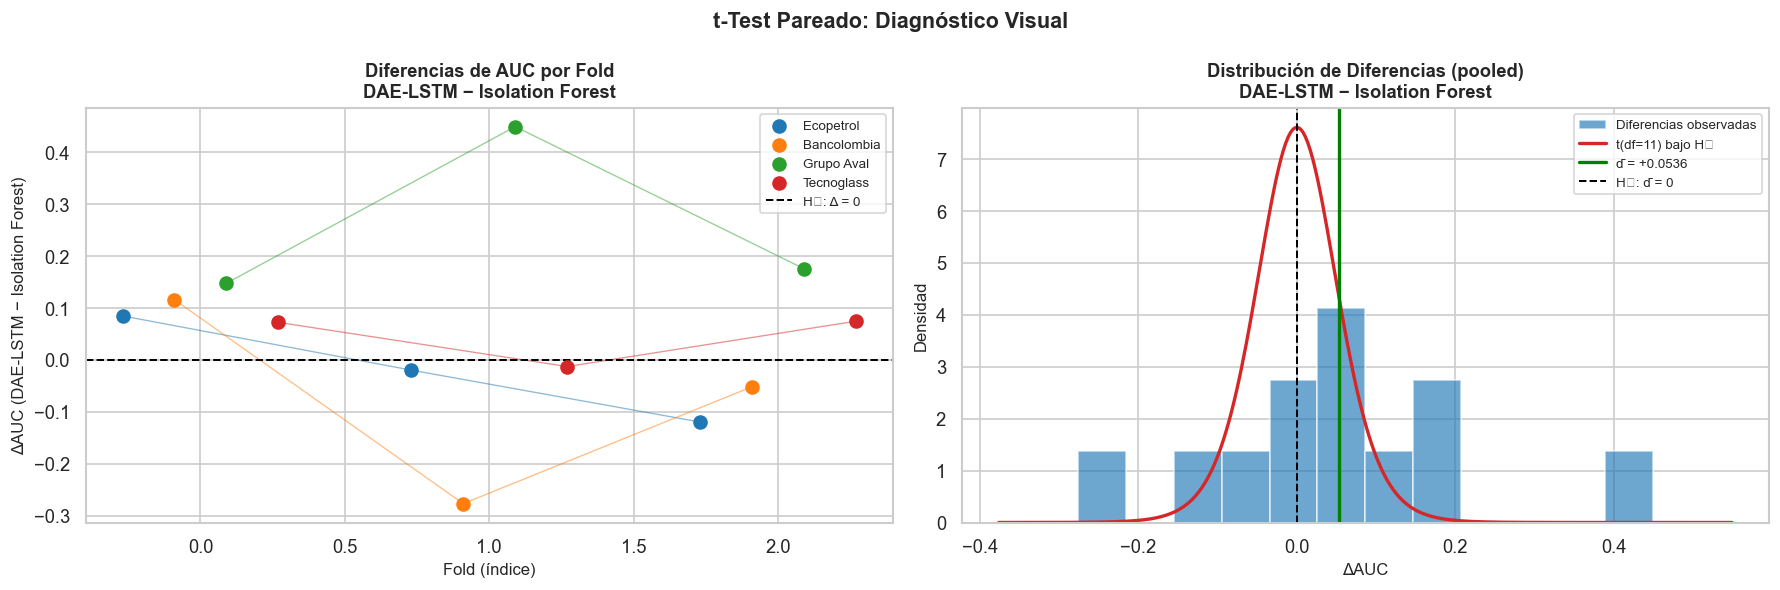

In [18]:
# ── Visualización de las diferencias y test ──────────────────────────────────
comp_viz = ('DAE-LSTM', 'Isolation Forest')
ma, mb   = comp_viz

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Panel izquierdo: diferencias por fold para cada activo ───────────────────
offset = 0
fold_positions = np.arange(N_FOLDS)
colors_tickers = list(COLORS.values())

for j, ticker in enumerate(TICKERS):
    a_arr, b_arr = get_clean_pair(ticker, ma, mb)
    if len(a_arr) == 0:
        continue
    diff = a_arr - b_arr
    n    = len(diff)
    pos  = np.arange(n) + j * 0.18 - 0.27

    axes[0].scatter(pos, diff, color=colors_tickers[j], s=60,
                    zorder=5, label=NAMES[ticker])
    axes[0].plot(pos, diff, color=colors_tickers[j],
                 linewidth=0.8, alpha=0.5)

axes[0].axhline(0, color='black', linewidth=1.2, linestyle='--',
                label='H₀: Δ = 0')
axes[0].set_xlabel('Fold (índice)')
axes[0].set_ylabel(f'ΔAUC ({ma} − {mb})')
axes[0].set_title(
    f'Diferencias de AUC por Fold\n{ma} − {mb}',
    fontweight='bold'
)
axes[0].legend(fontsize=8)

# ── Panel derecho: distribución de las diferencias + t-distribución ───────────
all_diffs = []
for ticker in TICKERS:
    a_arr, b_arr = get_clean_pair(ticker, ma, mb)
    if len(a_arr) >= 2:
        all_diffs.extend((a_arr - b_arr).tolist())
all_diffs = np.array(all_diffs)

if len(all_diffs) >= 3:
    axes[1].hist(all_diffs, bins=12, density=True,
                 color='#1f77b4', alpha=0.65, edgecolor='white',
                 label='Diferencias observadas')

    # t-distribución bajo H₀ centrada en 0
    x_t   = np.linspace(all_diffs.min() - 0.1, all_diffs.max() + 0.1, 300)
    df_p  = len(all_diffs) - 1
    se_p  = all_diffs.std(ddof=1) / np.sqrt(len(all_diffs))
    pdf_t = t_dist.pdf(x_t, df_p, loc=0, scale=se_p)
    axes[1].plot(x_t, pdf_t, color='#d62728', linewidth=2.0,
                 label=f't(df={df_p}) bajo H₀')

    axes[1].axvline(all_diffs.mean(), color='green', linewidth=2.0,
                    linestyle='-', label=f'd̄ = {all_diffs.mean():+.4f}')
    axes[1].axvline(0, color='black', linewidth=1.2, linestyle='--',
                    label='H₀: d̄ = 0')

axes[1].set_title(
    f'Distribución de Diferencias (pooled)\n{ma} − {mb}',
    fontweight='bold'
)
axes[1].set_xlabel('ΔAUC')
axes[1].set_ylabel('Densidad')
axes[1].legend(fontsize=8)

plt.suptitle('t-Test Pareado: Diagnóstico Visual', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_ttest_visual.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Test de Rangos con Signo de Wilcoxon

### **4.1 Motivación y supuestos**

El test de Wilcoxon (1945) es la alternativa no paramétrica al t-test
pareado. No asume normalidad de las diferencias — sólo requiere que
la distribución de las diferencias sea continua y simétrica alrededor
de la mediana.

Es preferible al t-test cuando:
- El tamaño muestral es pequeño (K < 10 folds).
- Las diferencias muestran asimetría o colas pesadas.
- El diagnóstico de Shapiro-Wilk rechaza la normalidad.

### **4.2 Procedimiento**

```
Paso 1: Calcular diferencias dₖ = AUC_A(k) − AUC_B(k)
Paso 2: Descartar dₖ = 0 (empates)
Paso 3: Ordenar |dₖ| de menor a mayor → asignar rangos Rₖ
Paso 4: Calcular W⁺ = Σ Rₖ · I(dₖ > 0)  [suma de rangos positivos]
         y       W⁻ = Σ Rₖ · I(dₖ < 0)  [suma de rangos negativos]

Estadístico: W = min(W⁺, W⁻)

H₀: La mediana de las diferencias es 0
H₁: La mediana de las diferencias ≠ 0  (bilateral)
```

### **4.3 Ventaja sobre el t-test en este contexto**

Con sólo 6 folds por activo, el teorema central del límite no garantiza
la aproximación normal del t-test. El Wilcoxon, al operar sobre rangos,
es robusto ante outliers y no depende de la normalidad de las diferencias.

In [19]:
# ── Test de Wilcoxon: implementación y resultados ─────────────────────────────
def wilcoxon_test(ticker, model_a, model_b, alpha=ALPHA):
    """
    Ejecuta el test de rangos con signo de Wilcoxon.

    Notas
    -----
    - zero_method='wilcox': descarta empates (dₖ = 0)
    - alternative='two-sided': prueba bilateral
    - mode='auto': usa aproximación exacta si n <= 25, normal si n > 25
    """
    a_arr, b_arr = get_clean_pair(ticker, model_a, model_b)
    n    = len(a_arr)

    if n < 2:
        return {'error': f'Solo {n} pares — insuficiente.'}

    diff = a_arr - b_arr

    # Manejar empates exactos (scipy los descarta automáticamente)
    try:
        w_stat, p_val = wilcoxon(diff,
                                  zero_method='wilcox',
                                  alternative='two-sided',
                                  mode='auto')
    except ValueError as e:
        return {'error': str(e)}

    decision = 'RECHAZAR H₀' if p_val < alpha else 'NO RECHAZAR H₀'

    return {
        'ticker':    ticker,
        'model_a':   model_a,
        'model_b':   model_b,
        'n_pairs':   n,
        'median_diff': np.median(diff),
        'W_stat':    w_stat,
        'p_value':   p_val,
        'alpha':     alpha,
        'decision':  decision,
        'sign':      p_val < alpha,
    }


# Pooled: concatenar diferencias de todos los activos para aumentar potencia
def wilcoxon_pooled(model_a, model_b, alpha=ALPHA):
    """
    Aplica Wilcoxon sobre las diferencias pooled de todos los activos.
    Incrementa la potencia estadística al aumentar n.
    """
    all_diffs = []
    for ticker in TICKERS:
        a_arr, b_arr = get_clean_pair(ticker, model_a, model_b)
        if len(a_arr) >= 2:
            all_diffs.extend((a_arr - b_arr).tolist())
    all_diffs = np.array(all_diffs)
    n = len(all_diffs)

    if n < 2:
        return {'error': 'Insuficientes pares.'}

    try:
        w_stat, p_val = wilcoxon(all_diffs, zero_method='wilcox',
                                  alternative='two-sided', mode='auto')
    except ValueError as e:
        return {'error': str(e)}

    return {
        'model_a': model_a, 'model_b': model_b,
        'n_pairs': n,
        'median_diff': np.median(all_diffs),
        'W_stat': w_stat, 'p_value': p_val,
        'decision': 'RECHAZAR H₀' if p_val < alpha else 'NO RECHAZAR H₀',
        'sign': p_val < alpha
    }


# ── Resultados por activo ────────────────────────────────────────────────────
wilcoxon_results = {}
print("TEST DE WILCOXON (RANGOS CON SIGNO) — Por Activo")
print("=" * 78)
print(f"{'Comparación':<32}  {'Activo':<14}  {'N':>4}  "
      f"{'Mediana Δ':>10}  {'W-stat':>8}  {'p-valor':>10}  {'Decisión'}")
print('-' * 90)

for (ma, mb) in comparisons:
    comp_key = f'{ma} vs {mb}'
    wilcoxon_results[comp_key] = {}
    for ticker in TICKERS:
        res = wilcoxon_test(ticker, ma, mb)
        wilcoxon_results[comp_key][ticker] = res
        if 'error' in res:
            print(f"{comp_key[:30]:<32}  {NAMES[ticker]:<14}  {res['error']}")
            continue
        print(f"{comp_key[:30]:<32}  {NAMES[ticker]:<14}  "
              f"{res['n_pairs']:>4}  {res['median_diff']:>+10.4f}  "
              f"{res['W_stat']:>8.2f}  {res['p_value']:>10.6f}  "
              f"{res['decision']}")
    print()

# ── Resultados pooled ────────────────────────────────────────────────────────
print("TEST DE WILCOXON — Diferencias POOLED (todos los activos)")
print("=" * 78)
print(f"{'Comparación':<32}  {'N':>6}  "
      f"{'Mediana Δ':>10}  {'W-stat':>8}  {'p-valor':>10}  {'Decisión'}")
print('-' * 80)

for (ma, mb) in comparisons:
    res = wilcoxon_pooled(ma, mb)
    if 'error' in res:
        print(f"{(ma+' vs '+mb)[:30]:<32}  {res['error']}")
        continue
    print(f"{(ma+' vs '+mb)[:30]:<32}  {res['n_pairs']:>6}  "
          f"{res['median_diff']:>+10.4f}  {res['W_stat']:>8.2f}  "
          f"{res['p_value']:>10.6f}  {res['decision']}")


TEST DE WILCOXON (RANGOS CON SIGNO) — Por Activo
Comparación                       Activo             N   Mediana Δ    W-stat     p-valor  Decisión
------------------------------------------------------------------------------------------
DAE-LSTM vs Isolation Forest      Ecopetrol          3     -0.0194      2.00    0.750000  NO RECHAZAR H₀
DAE-LSTM vs Isolation Forest      Bancolombia        3     -0.0514      2.00    0.750000  NO RECHAZAR H₀
DAE-LSTM vs Isolation Forest      Grupo Aval         3     +0.1760      0.00    0.250000  NO RECHAZAR H₀
DAE-LSTM vs Isolation Forest      Tecnoglass         3     +0.0726      1.00    0.500000  NO RECHAZAR H₀

DAE-LSTM vs Z-Score               Ecopetrol          3     -0.1672      0.00    0.250000  NO RECHAZAR H₀
DAE-LSTM vs Z-Score               Bancolombia        3     +0.0035      3.00    1.000000  NO RECHAZAR H₀
DAE-LSTM vs Z-Score               Grupo Aval         3     +0.0668      1.00    0.500000  NO RECHAZAR H₀
DAE-LSTM vs Z-Score      

In [20]:
# ── Comparación t-test vs Wilcoxon: concordancia de decisiones ───────────────
print("CONCORDANCIA t-TEST vs WILCOXON")
print("=" * 68)
print(f"{'Comparación':<32}  {'Activo':<14}  {'t-test':>10}  {'Wilcoxon':>10}")
print('-' * 70)

for (ma, mb) in comparisons:
    comp_key = f'{ma} vs {mb}'
    for ticker in TICKERS:
        t_res = ttest_results.get(comp_key, {}).get(ticker, {})
        w_res = wilcoxon_results.get(comp_key, {}).get(ticker, {})

        if 'error' in t_res or 'error' in w_res:
            continue
        t_dec = 'Sig.' if t_res.get('sign', False) else 'NS'
        w_dec = 'Sig.' if w_res.get('sign', False) else 'NS'
        concordance = 'Concuerda' if t_dec == w_dec else 'DISCORDA'
        print(f"{comp_key[:30]:<32}  {NAMES[ticker]:<14}  "
              f"{t_dec:>10}  {w_dec:>10}  {concordance}")
    print()


CONCORDANCIA t-TEST vs WILCOXON
Comparación                       Activo              t-test    Wilcoxon
----------------------------------------------------------------------
DAE-LSTM vs Isolation Forest      Ecopetrol               NS          NS  Concuerda
DAE-LSTM vs Isolation Forest      Bancolombia             NS          NS  Concuerda
DAE-LSTM vs Isolation Forest      Grupo Aval              NS          NS  Concuerda
DAE-LSTM vs Isolation Forest      Tecnoglass              NS          NS  Concuerda

DAE-LSTM vs Z-Score               Ecopetrol               NS          NS  Concuerda
DAE-LSTM vs Z-Score               Bancolombia             NS          NS  Concuerda
DAE-LSTM vs Z-Score               Grupo Aval              NS          NS  Concuerda
DAE-LSTM vs Z-Score               Tecnoglass              NS          NS  Concuerda

DAE-LSTM vs DAE-GRU               Ecopetrol               NS          NS  Concuerda
DAE-LSTM vs DAE-GRU               Bancolombia             NS      

---
## Intervalos de Confianza Bootstrap

### **5.1 Motivación**

Los intervalos de confianza del t-test asumen normalidad. Para el AUC-ROC,
cuya distribución muestral puede ser asimétrica (especialmente con pocos
folds), el bootstrap proporciona intervalos más precisos sin asumir
ninguna distribución paramétrica.

### **5.2 Procedimiento BCa (Bias-Corrected and Accelerated)**

El bootstrap BCa (Efron, 1987) es el método estándar de referencia:

```
Para B = 10,000 iteraciones:
  1. Remuestrear con reemplazo los K pares (AUC_A, AUC_B)
  2. Calcular la diferencia media de AUC en la muestra bootstrap
  3. Ordenar los B valores bootstrap

IC₉₅% BCa = [percentil_corregido(2.5%), percentil_corregido(97.5%)]

La corrección BCa ajusta por:
  - Sesgo del estimador (bias correction z₀)
  - Aceleración de la varianza (acceleration a)
```

### **5.3 Interpretación**

```
Si el IC₉₅% del ΔAUC no contiene el 0:
  → El modelo A es estadísticamente superior a B (α = 5%)
  → Equivalente a rechazar H₀ en el t-test bilateral

Si el IC₉₅% contiene el 0 pero es positivo:
  → Tendencia favorable a A, pero sin significancia estadística
  → Se necesitan más datos (más folds o activos)
```

In [21]:
# ── Bootstrap IC para la diferencia de AUC ───────────────────────────────────
def bootstrap_ci(a_arr, b_arr, n_bootstrap=10_000,
                 alpha=ALPHA, random_state=SEED):
    """
    Calcula el IC bootstrap (percentil y BCa) para la diferencia
    media de AUC entre dos modelos.

    Parámetros
    ----------
    a_arr, b_arr : np.ndarray — AUCs pareados de los dos modelos
    n_bootstrap  : int — número de remuestreos
    alpha        : float — nivel de significancia (IC al (1-alpha)*100%)

    Retorna
    -------
    dict con IC percentil y BCa, estadístico observado y p-valor bootstrap
    """
    rng  = np.random.default_rng(random_state)
    n    = len(a_arr)
    diff = a_arr - b_arr
    obs  = diff.mean()

    # Bootstrap
    boot_stats = np.array([
        rng.choice(diff, size=n, replace=True).mean()
        for _ in range(n_bootstrap)
    ])

    # IC percentil
    ci_perc = np.percentile(boot_stats, [alpha/2*100, (1-alpha/2)*100])

    # BCa: corrección de sesgo y aceleración
    z0   = norm.ppf((boot_stats < obs).mean() + 1e-10)  # bias correction
    jack = np.array([np.delete(diff, i).mean() for i in range(n)])
    jack_mean = jack.mean()
    num  = np.sum((jack_mean - jack)**3)
    den  = 6 * (np.sum((jack_mean - jack)**2)**1.5)
    a_hat= num / den if den != 0 else 0  # acceleration

    z_alpha2 = norm.ppf(alpha / 2)
    z_1alpha2= norm.ppf(1 - alpha / 2)

    alpha1 = norm.cdf(z0 + (z0 + z_alpha2) / (1 - a_hat * (z0 + z_alpha2)))
    alpha2 = norm.cdf(z0 + (z0 + z_1alpha2)/ (1 - a_hat * (z0 + z_1alpha2)))

    ci_bca = np.percentile(boot_stats, [alpha1*100, alpha2*100])

    # p-valor bootstrap (bilateral)
    shifted  = boot_stats - obs        # centrado en 0 bajo H₀
    p_boot   = 2 * min((shifted >= obs).mean(), (shifted <= obs).mean())
    p_boot   = max(p_boot, 1 / n_bootstrap)  # límite inferior

    return {
        'observed': obs,
        'ci_perc':  ci_perc,
        'ci_bca':   ci_bca,
        'p_boot':   p_boot,
        'n':        n,
        'boot_stats': boot_stats,
    }


# ── Aplicar a todos los pares ────────────────────────────────────────────────
bootstrap_results = {}
print("INTERVALOS DE CONFIANZA BOOTSTRAP (BCa, 95%) — POOLED")
print("=" * 85)
print(f"{'Comparación':<34}  {'N':>5}  {'Δ̄AUC':>8}  "
      f"{'IC BCa Lo':>12}  {'IC BCa Hi':>12}  "
      f"{'p-boot':>10}  {'Sig.'}")
print('-' * 87)

for (ma, mb) in comparisons:
    all_a, all_b = [], []
    for ticker in TICKERS:
        a_arr, b_arr = get_clean_pair(ticker, ma, mb)
        if len(a_arr) >= 2:
            all_a.extend(a_arr.tolist())
            all_b.extend(b_arr.tolist())

    all_a, all_b = np.array(all_a), np.array(all_b)
    comp_key = f'{ma} vs {mb}'

    if len(all_a) < 2:
        print(f"{comp_key[:32]:<34}  Insuficientes pares.")
        continue

    res = bootstrap_ci(all_a, all_b)
    bootstrap_results[comp_key] = res

    sign_str = 'Sig.' if res['p_boot'] < ALPHA else 'NS'
    contains_zero = (res['ci_bca'][0] <= 0 <= res['ci_bca'][1])
    sign_ic  = '*' if not contains_zero else ' '

    print(f"{comp_key[:32]:<34}  {res['n']:>5}  "
          f"{res['observed']:>+8.4f}  "
          f"{res['ci_bca'][0]:>12.4f}  {res['ci_bca'][1]:>12.4f}  "
          f"{res['p_boot']:>10.6f}  {sign_str}{sign_ic}")


INTERVALOS DE CONFIANZA BOOTSTRAP (BCa, 95%) — POOLED
Comparación                             N     Δ̄AUC     IC BCa Lo     IC BCa Hi      p-boot  Sig.
---------------------------------------------------------------------------------------
DAE-LSTM vs Isolation Forest           12   +0.0536       -0.0372        0.1548    0.278600  NS 
DAE-LSTM vs Z-Score                    12   -0.0287       -0.1436        0.2130    0.775200  NS 
DAE-LSTM vs DAE-GRU                    12   +0.0066       -0.0023        0.0185    0.210200  NS 
DAE-GRU vs Isolation Forest            12   +0.0471       -0.0454        0.1522    0.362800  NS 
DAE-GRU vs Z-Score                     12   -0.0353       -0.1525        0.2105    0.723200  NS 


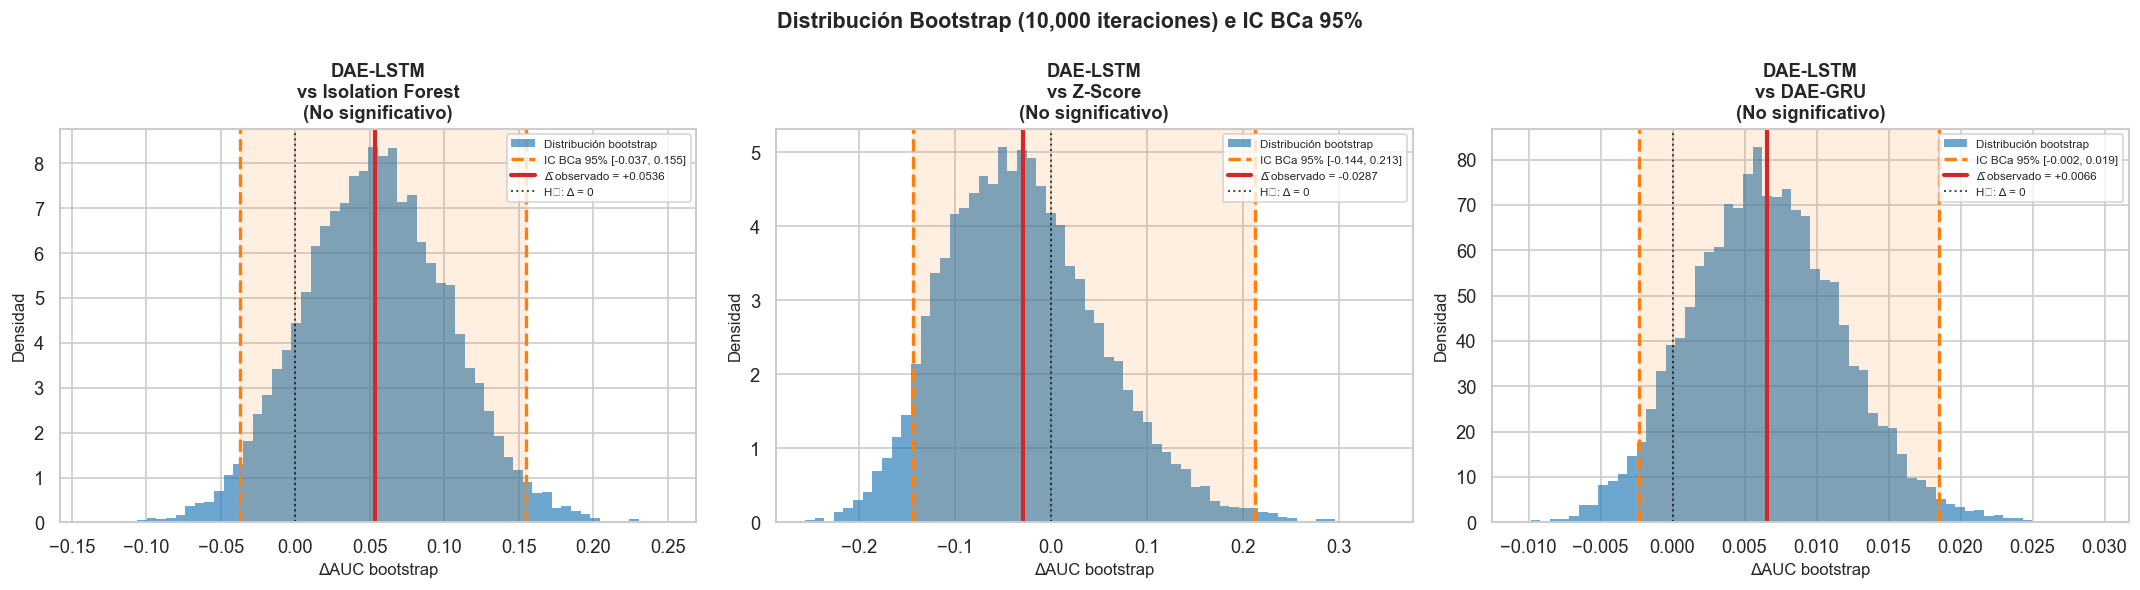

In [23]:
# ── Visualización: distribución bootstrap y CI ───────────────────────────────
comps_viz = [
    ('DAE-LSTM', 'Isolation Forest'),
    ('DAE-LSTM', 'Z-Score'),
    ('DAE-LSTM', 'DAE-GRU'),
]

fig, axes = plt.subplots(1, len(comps_viz), figsize=(18, 5))

for j, (ma, mb) in enumerate(comps_viz):
    comp_key = f'{ma} vs {mb}'
    if comp_key not in bootstrap_results:
        continue
    res     = bootstrap_results[comp_key]
    bs      = res['boot_stats']
    obs     = res['observed']
    ci_bca  = res['ci_bca']

    axes[j].hist(bs, bins=60, density=True,
                 color='#1f77b4', alpha=0.65, edgecolor='none',
                 label='Distribución bootstrap')

    # IC BCa
    axes[j].axvline(ci_bca[0], color='#ff7f0e', linewidth=2.0,
                    linestyle='--', label=f'IC BCa 95% [{ci_bca[0]:.3f}, {ci_bca[1]:.3f}]')
    axes[j].axvline(ci_bca[1], color='#ff7f0e', linewidth=2.0, linestyle='--')
    axes[j].axvspan(ci_bca[0], ci_bca[1], alpha=0.12, color='#ff7f0e')

    # Valor observado
    axes[j].axvline(obs, color='#d62728', linewidth=2.5,
                    linestyle='-', label=f'Δ̄ observado = {obs:+.4f}')
    axes[j].axvline(0, color='black', linewidth=1.2, linestyle=':',
                    alpha=0.7, label='H₀: Δ = 0')

    # Región de rechazo
    if not (ci_bca[0] <= 0 <= ci_bca[1]):
        axes[j].set_facecolor('#fff0f0')
        sig_text = 'Significativo'
    else:
        sig_text = 'No significativo'

    axes[j].set_title(
        f'{ma}\nvs {mb}\n({sig_text})',
        fontweight='bold'
    )
    axes[j].set_xlabel('ΔAUC bootstrap')
    axes[j].set_ylabel('Densidad')
    axes[j].legend(fontsize=7)

plt.suptitle('Distribución Bootstrap (10,000 iteraciones) e IC BCa 95%',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_bootstrap_ci.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Test de Diebold-Mariano

### **6.1 Motivación**

El test de Diebold-Mariano (DM, 1995) fue diseñado específicamente para
comparar la precisión de pronósticos en series temporales. A diferencia
del t-test y Wilcoxon, que operan sobre métricas agregadas por fold,
el DM opera sobre las **series temporales de errores de predicción**,
aprovechando toda la información disponible observación por observación.

### **6.2 Formulación**

```
Sea e₁_t = pérdida del modelo 1 en t  (en nuestro caso: MSE de reconstrucción)
    e₂_t = pérdida del modelo 2 en t

Diferencia de pérdidas: dₜ = g(e₁_t) − g(e₂_t)
  g(·) = función de pérdida (aquí: g(e) = e²)

H₀: E[dₜ] = 0    (igual precisión de pronóstico)
H₁: E[dₜ] ≠ 0   (diferencia en precisión)

Estadístico DM: S = d̄ / √(σ̂²_d / T)

donde σ̂²_d es la varianza de largo plazo de dₜ (ajustada por autocorrelación).

Bajo H₀: S ~ N(0,1) asintóticamente.
```

### **6.3 Ventaja sobre el t-test**

El estimador de varianza de largo plazo corrige el sesgo de autocorrelación
en los errores: si los errores del modelo son serialmente correlacionados
(esperado en series temporales financieras), el t-test estándar subestima
el error estándar y sobreestima la significancia. El DM corrige esto.

In [24]:
# ── Test de Diebold-Mariano ───────────────────────────────────────────────────
def diebold_mariano(e1, e2, h=1, alpha=ALPHA):
    """
    Test de Diebold-Mariano para comparación de errores de predicción.

    Parámetros
    ----------
    e1, e2 : np.ndarray — series de pérdidas (MSE) de los dos modelos
    h      : int — horizonte de predicción (1 para un paso)
    alpha  : float — nivel de significancia

    Retorna
    -------
    dict con estadístico DM, p-valor e interpretación
    """
    n    = min(len(e1), len(e2))
    e1, e2 = e1[:n], e2[:n]
    d    = e1 - e2           # diferencia de pérdidas

    d_bar= d.mean()
    T    = len(d)

    # Estimador de varianza de largo plazo (kernel rectangular, ventana h-1)
    # Para h=1, coincide con la varianza muestral ajustada
    gamma0 = np.var(d, ddof=0)
    gamma  = np.array([
        np.cov(d[k:], d[:-k])[0,1] if k > 0 and k < T else 0
        for k in range(1, h)
    ])
    lrv    = gamma0 + 2 * gamma.sum() if len(gamma) > 0 else gamma0
    lrv    = max(lrv, 1e-10)

    dm_stat= d_bar / np.sqrt(lrv / T)
    p_val  = 2 * norm.sf(abs(dm_stat))   # bilateral

    decision = 'RECHAZAR H₀' if p_val < alpha else 'NO RECHAZAR H₀'

    return {
        'n': n,
        'mean_diff_loss': d_bar,
        'dm_stat': dm_stat,
        'p_value': p_val,
        'decision': decision,
        'sign': p_val < alpha,
        'd_series': d,
    }


# ── Aplicar sobre el conjunto test (2021-2024) usando los MSE completos ───────
# Primero necesitamos re-entrenar y obtener las series MSE para test

print("Obteniendo series de MSE para el test DM...")

# Entrenamiento rápido de los modelos para un activo piloto
ticker_dm = 'EC'
d_dm      = data[ticker_dm]

dae_lstm_dm = build_dae('LSTM')
train_model(dae_lstm_dm, d_dm['wins']['train'], d_dm['wins']['val'])

dae_gru_dm  = build_dae('GRU')
train_model(dae_gru_dm,  d_dm['wins']['train'], d_dm['wins']['val'])

# MSE serie temporal en test
mse_lstm_dm = mse_score(dae_lstm_dm, d_dm['wins']['test'])
mse_gru_dm  = mse_score(dae_gru_dm,  d_dm['wins']['test'])
mse_if_dm   = if_score(
    d_dm['wins']['train'].reshape(d_dm['wins']['train'].shape[0], -1),
    d_dm['wins']['test'].reshape( d_dm['wins']['test'].shape[0],  -1)
)
mse_zs_dm   = mahal_score(
    d_dm['wins']['train'].mean(axis=1),
    d_dm['wins']['test'].mean(axis=1)
)

print("Series MSE obtenidas. Ejecutando test DM...")
print()

dm_comparisons = [
    ('DAE-LSTM', 'DAE-GRU',          mse_lstm_dm, mse_gru_dm),
    ('DAE-LSTM', 'Isolation Forest', mse_lstm_dm, mse_if_dm),
    ('DAE-LSTM', 'Z-Score',          mse_lstm_dm, mse_zs_dm),
    ('DAE-GRU',  'Isolation Forest', mse_gru_dm,  mse_if_dm),
]

print(f"TEST DE DIEBOLD-MARIANO — {NAMES[ticker_dm]} (Test set)")
print("=" * 75)
print(f"{'Comparación':<35}  {'N':>6}  {'Δ̄Loss':>10}  "
      f"{'DM stat':>10}  {'p-valor':>10}  {'Decisión'}")
print('-' * 82)

dm_results = {}
for (ma, mb, e1, e2) in dm_comparisons:
    comp_key = f'{ma} vs {mb}'
    res = diebold_mariano(e1, e2)
    dm_results[comp_key] = res
    print(f"{comp_key[:33]:<35}  {res['n']:>6}  "
          f"{res['mean_diff_loss']:>+10.6f}  "
          f"{res['dm_stat']:>10.4f}  {res['p_value']:>10.6f}  "
          f"{res['decision']}")


Obteniendo series de MSE para el test DM...
Series MSE obtenidas. Ejecutando test DM...

TEST DE DIEBOLD-MARIANO — Ecopetrol (Test set)
Comparación                               N      Δ̄Loss     DM stat     p-valor  Decisión
----------------------------------------------------------------------------------
DAE-LSTM vs DAE-GRU                     975   -0.028908    -20.2234    0.000000  RECHAZAR H₀
DAE-LSTM vs Isolation Forest            975   +0.642782    107.5900    0.000000  RECHAZAR H₀
DAE-LSTM vs Z-Score                     975   -0.994970    -46.6319    0.000000  RECHAZAR H₀
DAE-GRU vs Isolation Forest             975   +0.671691    103.3807    0.000000  RECHAZAR H₀


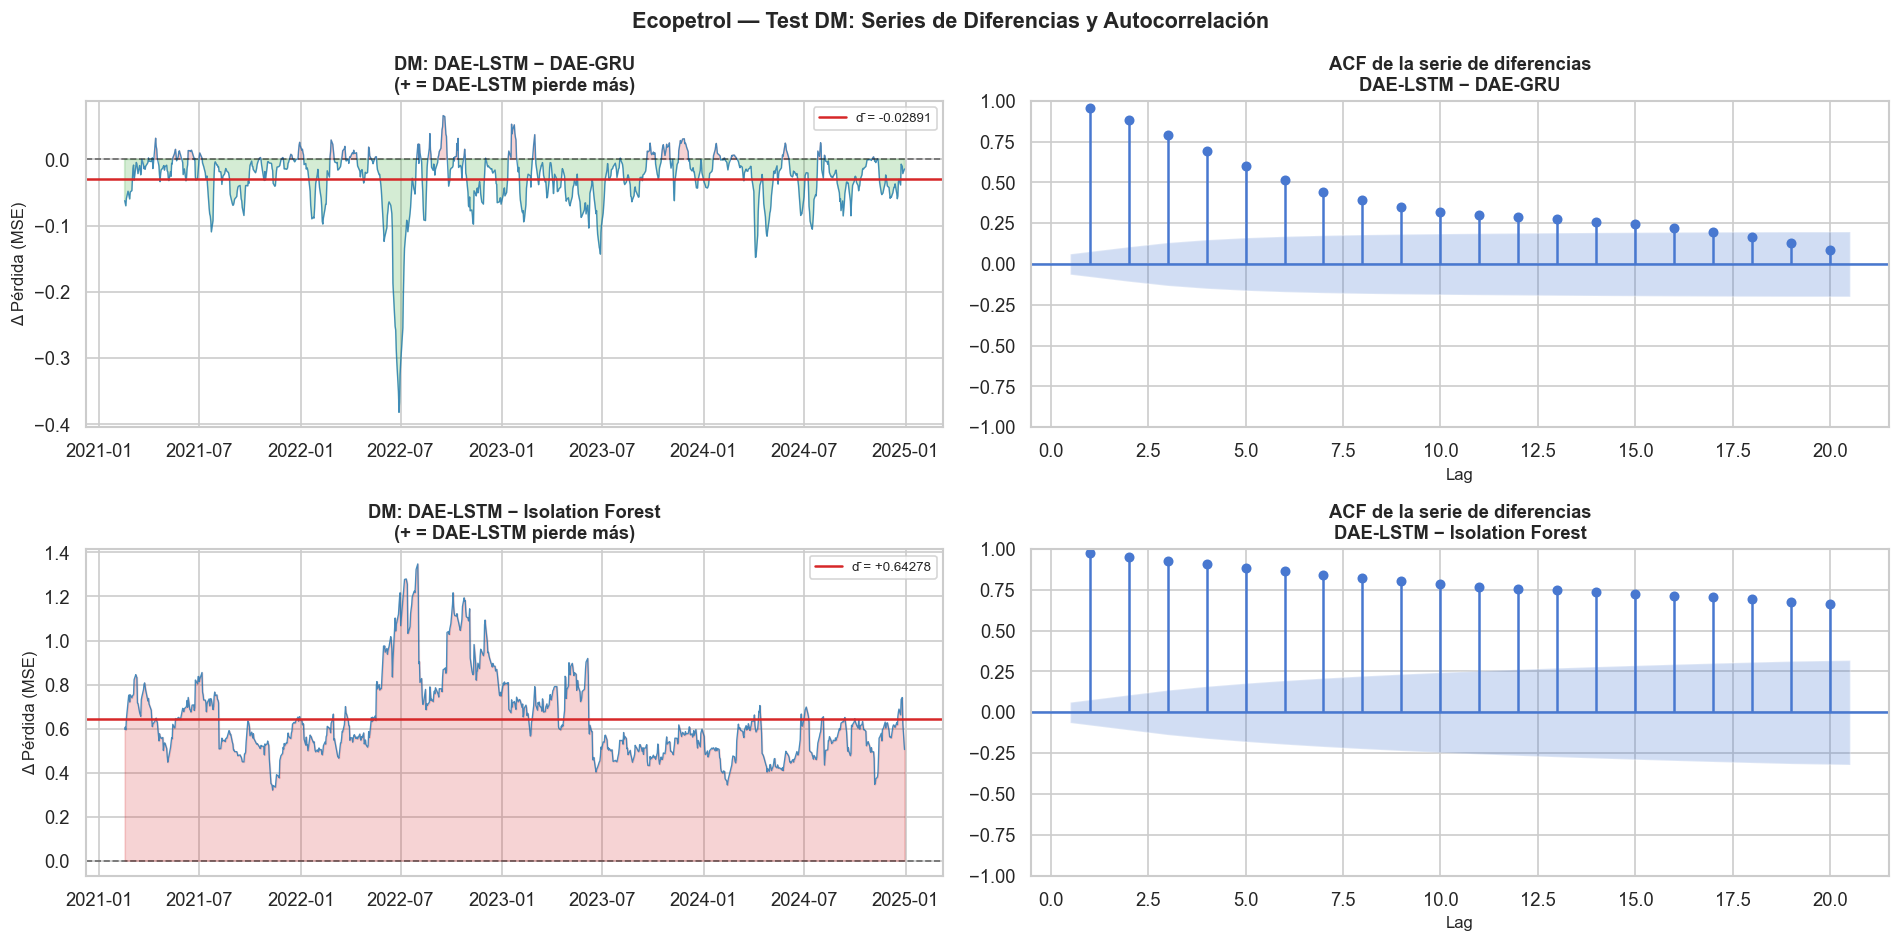

In [26]:
# ── Visualización: serie de diferencias de pérdidas DM ───────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=False)

dm_viz_list = [
    ('DAE-LSTM', 'DAE-GRU',          mse_lstm_dm, mse_gru_dm),
    ('DAE-LSTM', 'Isolation Forest', mse_lstm_dm, mse_if_dm),
]

dates_dm = data[ticker_dm]['dates']['test'][:min(
    len(mse_lstm_dm), len(mse_gru_dm), len(mse_if_dm), len(mse_zs_dm)
)]

for idx, (ma, mb, e1, e2) in enumerate(dm_viz_list):
    n = min(len(e1), len(e2), len(dates_dm))
    d_series = (e1 - e2)[:n]
    res      = dm_results.get(f'{ma} vs {mb}', {})

    # Serie de diferencias
    ax_top = axes[idx, 0]
    ax_top.plot(dates_dm[:n], d_series,
                color='#1f77b4', linewidth=0.8, alpha=0.8)
    ax_top.axhline(0, color='black', linewidth=1.0, linestyle='--', alpha=0.5)
    ax_top.axhline(d_series.mean(), color='#d62728', linewidth=1.5,
                   linestyle='-', label=f'd̄ = {d_series.mean():+.5f}')
    ax_top.fill_between(dates_dm[:n], 0, d_series,
                        where=d_series > 0, color='#d62728', alpha=0.2)
    ax_top.fill_between(dates_dm[:n], 0, d_series,
                        where=d_series < 0, color='#2ca02c', alpha=0.2)
    ax_top.set_title(
        f'DM: {ma} − {mb}\n(+ = {ma} pierde más)',
        fontweight='bold'
    )
    ax_top.set_ylabel('Δ Pérdida (MSE)')
    ax_top.legend(fontsize=8)

    # ACF de las diferencias
    ax_bot = axes[idx, 1]
    from statsmodels.graphics.tsaplots import plot_acf
    plot_acf(d_series, lags=20, ax=ax_bot, zero=False, alpha=0.05)
    ax_bot.set_title(
        f'ACF de la serie de diferencias\n{ma} − {mb}',
        fontweight='bold'
    )
    ax_bot.set_xlabel('Lag')

plt.suptitle(
    f'{NAMES[ticker_dm]} — Test DM: Series de Diferencias y Autocorrelación',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('fig_diebold_mariano.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Corrección por Comparaciones Múltiples

### **7.1 El problema del FWER**

Cuando se realizan múltiples pruebas estadísticas simultáneamente,
la probabilidad de obtener al menos un falso positivo crece rápidamente:

```
P(al menos un error tipo I) = 1 − (1 − α)^m

Con α = 0.05 y m = 10 comparaciones:
  P(≥ 1 falso positivo) = 1 − 0.95¹⁰ ≈ 0.40

Es decir, con 10 comparaciones al nivel 5%, la probabilidad de declarar
al menos una diferencia significativa por azar es del 40%.
```

### **7.2 Correcciones implementadas**

**Corrección de Bonferroni (FWER):**
```
α_corregido = α / m
Rechazar H₀_i si p_i < α / m

Conservadora — controla la tasa de error familiar (FWER).
Apropiada cuando cualquier falso positivo es inaceptable.
```

**Corrección de Benjamini-Hochberg (FDR):**
```
Ordenar p-valores: p_(1) ≤ p_(2) ≤ … ≤ p_(m)
Rechazar H₀_(i) si p_(i) ≤ (i/m) · q*   (q* = tasa FDR objetivo)

Menos conservadora — controla la Tasa de Descubrimientos Falsos (FDR).
Apropiada cuando se acepta una fracción q* de falsos positivos.
```

In [27]:
# ── Corrección por comparaciones múltiples ───────────────────────────────────
# Recopilar todos los p-valores de los tests anteriores

all_pvalues  = []
all_comp_ids = []

# p-valores del t-test (pooled por activo)
for (ma, mb) in comparisons:
    comp_key = f'{ma} vs {mb} (t-test)'
    # Usar las diferencias pooled para el t-test
    all_a, all_b = [], []
    for ticker in TICKERS:
        a_arr, b_arr = get_clean_pair(ticker, ma, mb)
        if len(a_arr) >= 2:
            all_a.extend(a_arr.tolist())
            all_b.extend(b_arr.tolist())

    all_a, all_b = np.array(all_a), np.array(all_b)
    if len(all_a) >= 2:
        diff    = all_a - all_b
        t_stat_p, p_val_p = ttest_rel(all_a, all_b)
        all_pvalues.append(p_val_p)
        all_comp_ids.append(comp_key)

# p-valores del Wilcoxon pooled
for (ma, mb) in comparisons:
    comp_key = f'{ma} vs {mb} (Wilcoxon)'
    res_w = wilcoxon_pooled(ma, mb)
    if 'error' not in res_w:
        all_pvalues.append(res_w['p_value'])
        all_comp_ids.append(comp_key)

# p-valores del DM
for (ma, mb, _, _) in dm_comparisons:
    comp_key = f'{ma} vs {mb} (DM)'
    k = f'{ma} vs {mb}'
    if k in dm_results:
        all_pvalues.append(dm_results[k]['p_value'])
        all_comp_ids.append(comp_key)

# p-valores bootstrap
for (ma, mb) in comparisons:
    comp_key_b = f'{ma} vs {mb}'
    if comp_key_b in bootstrap_results:
        all_pvalues.append(bootstrap_results[comp_key_b]['p_boot'])
        all_comp_ids.append(f'{comp_key_b} (bootstrap)')

m = len(all_pvalues)
p_arr = np.array(all_pvalues)

# Corrección de Bonferroni
reject_bonf, p_bonf, _, _ = multipletests(p_arr, alpha=ALPHA,
                                            method='bonferroni')

# Corrección de Benjamini-Hochberg (FDR)
reject_bh, p_bh, _, _ = multipletests(p_arr, alpha=ALPHA, method='fdr_bh')

# Resultados
print(f"CORRECCIÓN POR COMPARACIONES MÚLTIPLES (m = {m} pruebas, α = {ALPHA})")
print("=" * 95)
print(f"{'Comparación':<45}  {'p orig':>10}  "
      f"{'p Bonf.':>10}  {'Sig. Bonf.':>12}  "
      f"{'p BH':>10}  {'Sig. BH':>10}")
print('-' * 100)

for i, (comp, p, pb, rb, pbh, rbh) in enumerate(
    zip(all_comp_ids, p_arr, p_bonf, reject_bonf, p_bh, reject_bh)
):
    mark_b  = '   *' if rb  else '    '
    mark_bh = '   *' if rbh else '    '
    print(f"{comp[:43]:<45}  {p:>10.6f}  "
          f"{pb:>10.6f}  {('Sig.'+mark_b):>12}  "
          f"{pbh:>10.6f}  {('Sig.'+mark_bh):>10}")

print()
print(f"Bonferroni α_corregido = {ALPHA}/{m} = {ALPHA/m:.6f}")
print(f"BH q* = {ALPHA} (tasa FDR objetivo)")
print(f"Pruebas significativas (sin corrección): "
      f"{(p_arr < ALPHA).sum()}/{m}")
print(f"Pruebas significativas (Bonferroni):     "
      f"{reject_bonf.sum()}/{m}")
print(f"Pruebas significativas (BH-FDR):         "
      f"{reject_bh.sum()}/{m}")


CORRECCIÓN POR COMPARACIONES MÚLTIPLES (m = 19 pruebas, α = 0.05)
Comparación                                        p orig     p Bonf.    Sig. Bonf.        p BH     Sig. BH
----------------------------------------------------------------------------------------------------
DAE-LSTM vs Isolation Forest (t-test)            0.317639    1.000000      Sig.        0.496859    Sig.    
DAE-LSTM vs Z-Score (t-test)                     0.743729    1.000000      Sig.        0.775200    Sig.    
DAE-LSTM vs DAE-GRU (t-test)                     0.256256    1.000000      Sig.        0.496859    Sig.    
DAE-GRU vs Isolation Forest (t-test)             0.392257    1.000000      Sig.        0.496859    Sig.    
DAE-GRU vs Z-Score (t-test)                      0.693672    1.000000      Sig.        0.775200    Sig.    
DAE-LSTM vs Isolation Forest (Wilcoxon)          0.301270    1.000000      Sig.        0.496859    Sig.    
DAE-LSTM vs Z-Score (Wilcoxon)                   0.301270    1.000000      Si

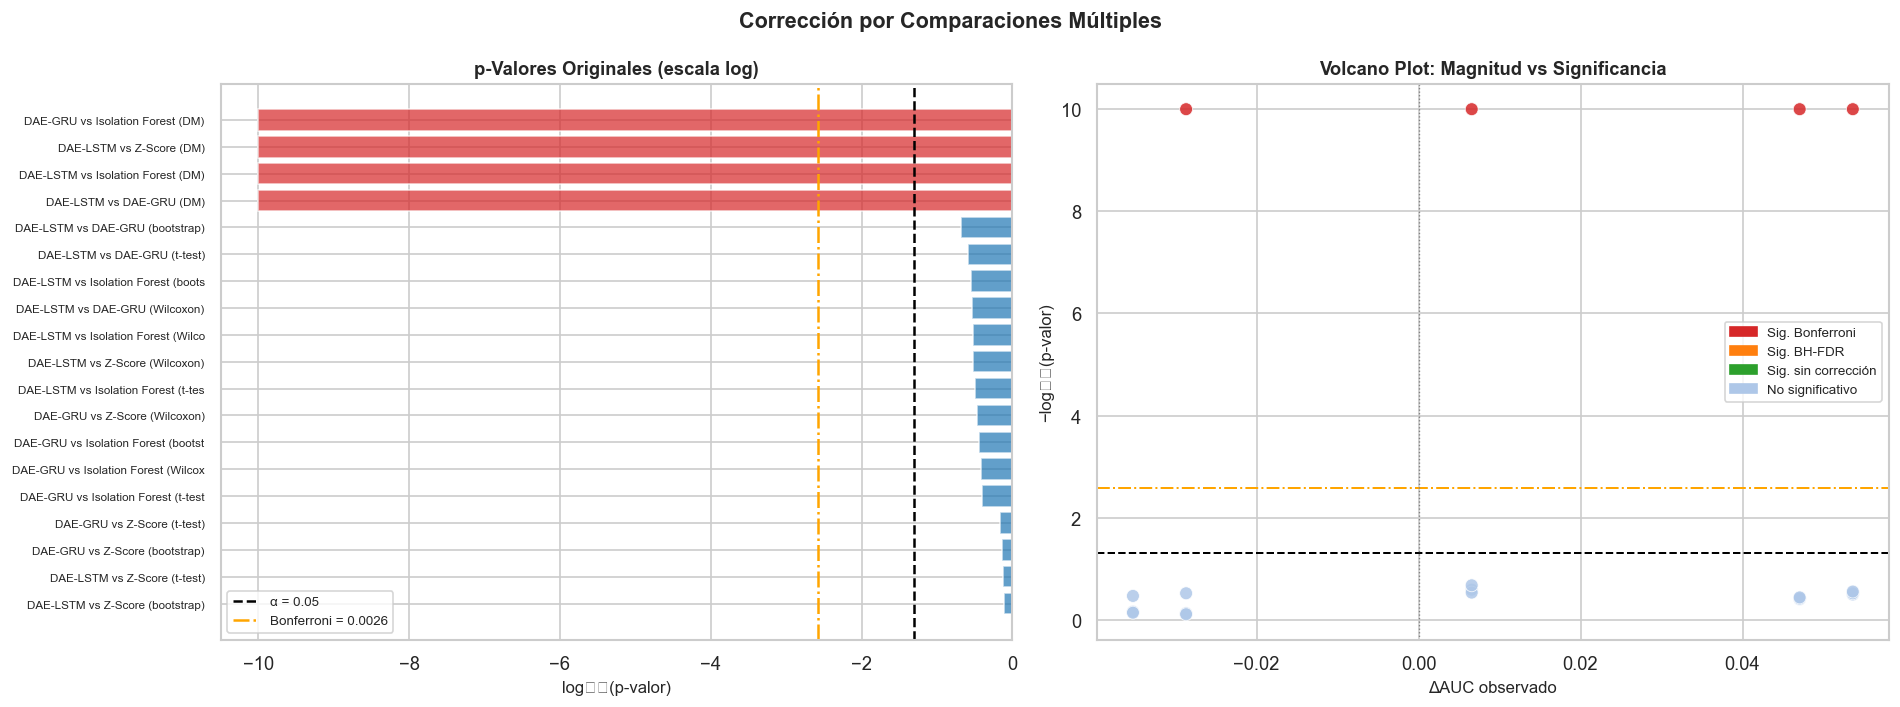

In [28]:
# ── Visualización: p-valores originales vs corregidos ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sorted_idx = np.argsort(p_arr)
p_sorted   = p_arr[sorted_idx]
ids_sorted = [all_comp_ids[i] for i in sorted_idx]
y_pos      = np.arange(len(p_sorted))

# ── Panel izquierdo: p-valores originales vs correcciones ────────────────────
axes[0].barh(y_pos, np.log10(p_sorted + 1e-10),
             color=['#d62728' if p < ALPHA else '#1f77b4'
                    for p in p_sorted],
             alpha=0.7, edgecolor='white')
axes[0].axvline(np.log10(ALPHA), color='black', linewidth=1.5,
                linestyle='--', label=f'α = {ALPHA}')
axes[0].axvline(np.log10(ALPHA / m), color='orange', linewidth=1.5,
                linestyle='-.', label=f'Bonferroni = {ALPHA/m:.4f}')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(
    [s[:35] for s in ids_sorted], fontsize=7
)
axes[0].set_xlabel('log₁₀(p-valor)')
axes[0].set_title('p-Valores Originales (escala log)', fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].invert_yaxis()

# ── Panel derecho: volcano plot ΔAUC vs −log₁₀(p) ───────────────────────────
delta_aucs = []
for comp_key, p in zip(all_comp_ids, p_arr):
    # Extraer el ΔAUC medio del resultado más cercano
    base = comp_key.replace(' (t-test)', '').replace(' (Wilcoxon)', '')                    .replace(' (DM)', '').replace(' (bootstrap)', '')
    if base in bootstrap_results:
        delta_aucs.append(bootstrap_results[base]['observed'])
    else:
        delta_aucs.append(0.0)

delta_aucs = np.array(delta_aucs)
neg_log_p  = -np.log10(p_arr + 1e-10)

scatter_colors = []
for p, rb, rbh in zip(p_arr, reject_bonf, reject_bh):
    if rb:
        scatter_colors.append('#d62728')    # rojo: sig. Bonferroni
    elif rbh:
        scatter_colors.append('#ff7f0e')    # naranja: sig. BH
    elif p < ALPHA:
        scatter_colors.append('#2ca02c')    # verde: sig. sin corrección
    else:
        scatter_colors.append('#aec7e8')    # azul: no significativo

axes[1].scatter(delta_aucs, neg_log_p, c=scatter_colors,
                s=60, alpha=0.85, edgecolors='white', linewidths=0.5)
axes[1].axhline(-np.log10(ALPHA), color='black', linewidth=1.2,
                linestyle='--', label=f'α = {ALPHA}')
axes[1].axhline(-np.log10(ALPHA/m), color='orange', linewidth=1.2,
                linestyle='-.', label='Bonferroni')
axes[1].axvline(0, color='grey', linewidth=0.8, linestyle=':')

legend_patches = [
    mpatches.Patch(color='#d62728', label='Sig. Bonferroni'),
    mpatches.Patch(color='#ff7f0e', label='Sig. BH-FDR'),
    mpatches.Patch(color='#2ca02c', label='Sig. sin corrección'),
    mpatches.Patch(color='#aec7e8', label='No significativo'),
]
axes[1].legend(handles=legend_patches, fontsize=8)
axes[1].set_xlabel('ΔAUC observado')
axes[1].set_ylabel('−log₁₀(p-valor)')
axes[1].set_title('Volcano Plot: Magnitud vs Significancia', fontweight='bold')

plt.suptitle('Corrección por Comparaciones Múltiples',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_multiple_testing_correction.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Significancia Estadística vs. Significancia Práctica

### **8.1 La distinción fundamental**

Una diferencia estadísticamente significativa (p < α) no implica
que sea prácticamente relevante. Con muestras grandes, diferencias
ínfimas en AUC pueden ser estadísticamente significativas pero sin
valor operativo. Con muestras pequeñas, diferencias prácticas
importantes pueden no alcanzar significancia estadística.

### **8.2 Effect size: d de Cohen**

Para diferencias de métricas continuas, el tamaño del efecto se mide
con la d de Cohen:

```
d = (μ_A − μ_B) / s_pooled

donde s_pooled = √[(s²_A + s²_B) / 2]

Interpretación estándar (Cohen, 1988):
  |d| < 0.20  → efecto negligible
  |d| ∈ [0.20, 0.50) → efecto pequeño
  |d| ∈ [0.50, 0.80) → efecto mediano
  |d| ≥ 0.80  → efecto grande
```

### **8.3 Umbral de relevancia práctica para AUC**

En el dominio de detección de anomalías financieras, se propone el
siguiente umbral de relevancia práctica:

```
ΔAUC < 0.02  → diferencia negligible (ruido de estimación)
ΔAUC ∈ [0.02, 0.05) → diferencia pequeña (relevante sólo a escala)
ΔAUC ∈ [0.05, 0.10) → diferencia moderada (justifica mayor complejidad)
ΔAUC ≥ 0.10  → diferencia grande (clara superioridad operativa)
```

In [29]:
# ── Effect size y relevancia práctica ────────────────────────────────────────
def cohen_d(a_arr, b_arr):
    """
    Calcula la d de Cohen para muestras pareadas.
    En datos pareados, d = d̄ / s_d (media de diffs / std de diffs).
    """
    diff  = a_arr - b_arr
    d_bar = diff.mean()
    s_d   = diff.std(ddof=1)
    return d_bar / s_d if s_d > 0 else 0.0

def effect_size_label(d):
    ad = abs(d)
    if   ad < 0.20: return 'Negligible'
    elif ad < 0.50: return 'Pequeño'
    elif ad < 0.80: return 'Mediano'
    else:           return 'Grande'

def practical_relevance(delta_auc):
    ad = abs(delta_auc)
    if   ad < 0.02: return 'Negligible'
    elif ad < 0.05: return 'Pequeño'
    elif ad < 0.10: return 'Moderado'
    else:           return 'Grande'


print("SIGNIFICANCIA ESTADÍSTICA vs. PRÁCTICA — Análisis Comparativo")
print("=" * 95)
print(f"{'Comparación':<34}  {'ΔAUC':>8}  {'d Cohen':>9}  "
      f"{'Efecto':>12}  {'Rel. práct.':>13}  "
      f"{'p-val (BH)':>12}  {'Sig. BH':>9}  {'Veredicto'}")
print('-' * 100)

for i, (comp_id, p, rb, rbh) in enumerate(
    zip(all_comp_ids, p_arr, reject_bonf, reject_bh)
):
    # Obtener ΔAUC y d de Cohen
    base = comp_id.replace(' (t-test)','').replace(' (Wilcoxon)','')                   .replace(' (DM)','').replace(' (bootstrap)','')
    try:
        parts = base.split(' vs ')
        ma, mb = parts[0].strip(), parts[1].strip()
        all_a_loc, all_b_loc = [], []
        for ticker in TICKERS:
            aa, bb = get_clean_pair(ticker, ma, mb)
            if len(aa) >= 2:
                all_a_loc.extend(aa.tolist())
                all_b_loc.extend(bb.tolist())
        all_a_loc = np.array(all_a_loc)
        all_b_loc = np.array(all_b_loc)
        if len(all_a_loc) >= 2:
            d_auc  = (all_a_loc - all_b_loc).mean()
            cd     = cohen_d(all_a_loc, all_b_loc)
        else:
            d_auc = cd = 0.0
    except Exception:
        d_auc = cd = 0.0

    eff_label = effect_size_label(cd)
    prac_label= practical_relevance(d_auc)
    sig_bh    = 'Sig.' if rbh else 'NS'

    # Veredicto integrado
    if rbh and abs(d_auc) >= 0.05:
        verdict = 'Stat. + Pract. sig.'
    elif rbh and abs(d_auc) < 0.05:
        verdict = 'Stat. sig., pract. dudosa'
    elif not rbh and abs(d_auc) >= 0.05:
        verdict = 'Pract. sig., no stat.'
    else:
        verdict = 'Sin relevancia'

    print(f"{comp_id[:32]:<34}  {d_auc:>+8.4f}  {cd:>9.4f}  "
          f"{eff_label:>12}  {prac_label:>13}  "
          f"{p_bh[i]:>12.6f}  {sig_bh:>9}  {verdict}")


SIGNIFICANCIA ESTADÍSTICA vs. PRÁCTICA — Análisis Comparativo
Comparación                             ΔAUC    d Cohen        Efecto    Rel. práct.    p-val (BH)    Sig. BH  Veredicto
----------------------------------------------------------------------------------------------------
DAE-LSTM vs Isolation Forest (t-     +0.0536     0.3022       Pequeño       Moderado      0.496859         NS  Pract. sig., no stat.
DAE-LSTM vs Z-Score (t-test)         -0.0287    -0.0968    Negligible        Pequeño      0.775200         NS  Sin relevancia
DAE-LSTM vs DAE-GRU (t-test)         +0.0066     0.3457       Pequeño     Negligible      0.496859         NS  Sin relevancia
DAE-GRU vs Isolation Forest (t-t     +0.0471     0.2571       Pequeño        Pequeño      0.496859         NS  Sin relevancia
DAE-GRU vs Z-Score (t-test)          -0.0353    -0.1167    Negligible        Pequeño      0.775200         NS  Sin relevancia
DAE-LSTM vs Isolation Forest (Wi     +0.0536     0.3022       Pequeño       Mod

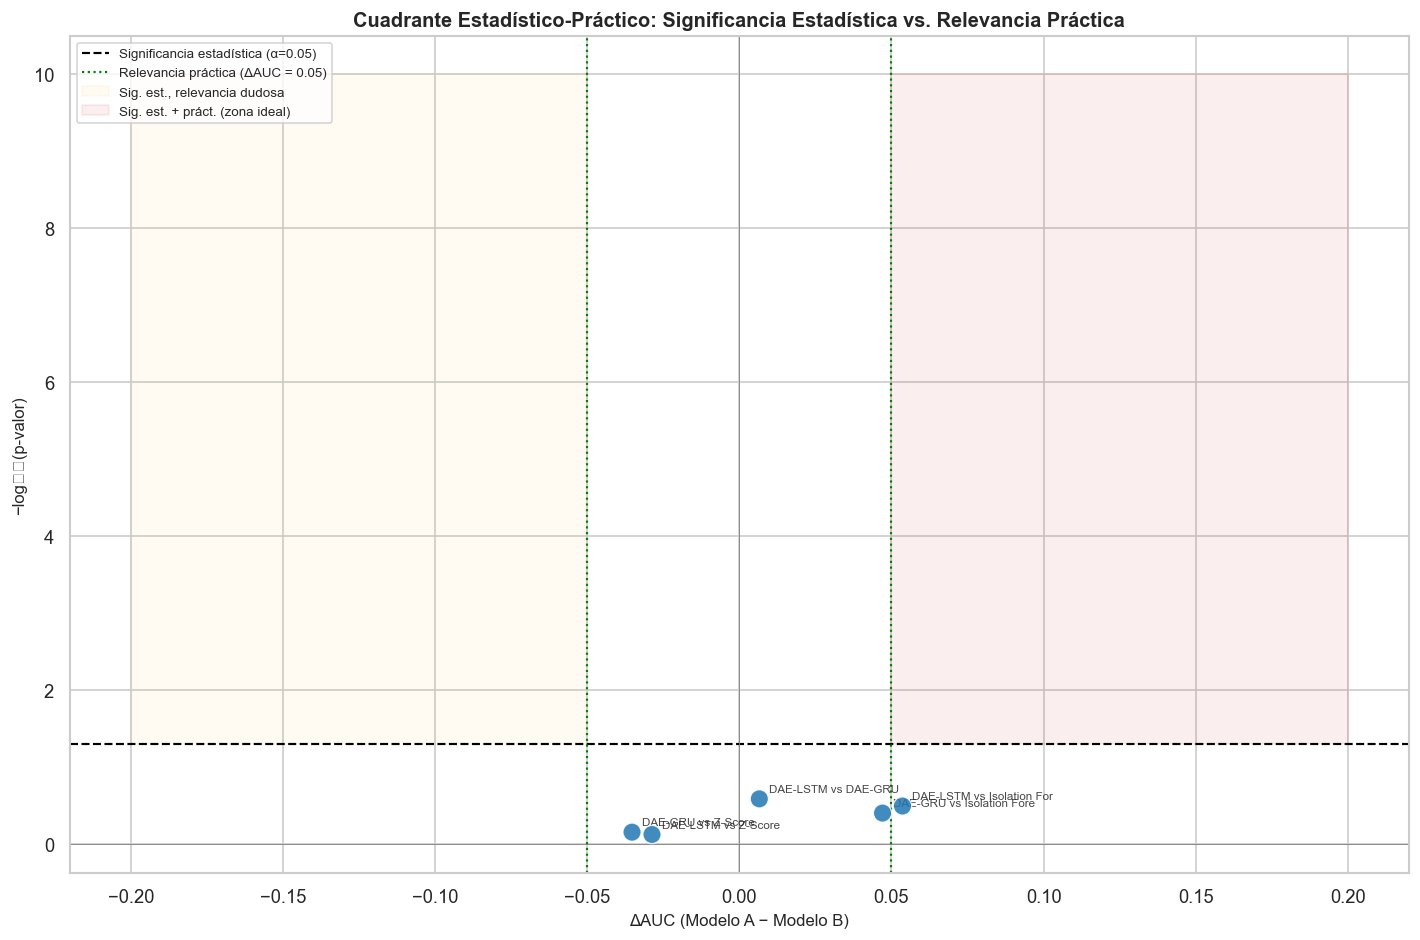

In [31]:
# ── Gráfica de cuadrantes: significancia estadística vs práctica ──────────────
fig, ax = plt.subplots(figsize=(12, 8))

# Recopilar datos para el scatter
scatter_data = []
for i, (comp_id, p) in enumerate(zip(all_comp_ids, p_arr)):
    base = comp_id.replace(' (t-test)','').replace(' (Wilcoxon)','') \
                  .replace(' (DM)','').replace(' (bootstrap)','')
    try:
        parts = base.split(' vs ')
        ma, mb = parts[0].strip(), parts[1].strip()
        all_a_s, all_b_s = [], []
        for ticker in TICKERS:
            aa, bb = get_clean_pair(ticker, ma, mb)
            if len(aa) >= 2:
                all_a_s.extend(aa.tolist())
                all_b_s.extend(bb.tolist())
        all_a_s, all_b_s = np.array(all_a_s), np.array(all_b_s)
        if len(all_a_s) >= 2:
            d_auc = (all_a_s - all_b_s).mean()
            neg_log = -np.log10(p + 1e-10)
            scatter_data.append((d_auc, neg_log, base, reject_bh[i]))
    except Exception:
        pass

# Quitar duplicados
seen = set()
unique_data = []
for row in scatter_data:
    if row[2] not in seen:
        seen.add(row[2])
        unique_data.append(row)

d_aucs_s  = [r[0] for r in unique_data]
neg_log_s = [r[1] for r in unique_data]
labels_s  = [r[2] for r in unique_data]
sig_s     = [r[3] for r in unique_data]

colors_s  = ['#d62728' if s else '#1f77b4' for s in sig_s]
ax.scatter(d_aucs_s, neg_log_s, c=colors_s, s=120, alpha=0.85,
           edgecolors='white', linewidths=0.8, zorder=5)

# Etiquetas
for x, y, lbl in zip(d_aucs_s, neg_log_s, labels_s):
    ax.annotate(lbl[:25], (x, y), textcoords='offset points',
                xytext=(6, 4), fontsize=7, alpha=0.85)

# Líneas de referencia
ax.axhline(-np.log10(ALPHA), color='black', linewidth=1.3,
           linestyle='--', label=f'Significancia estadística (α={ALPHA})')
ax.axvline(0.05,  color='green', linewidth=1.3, linestyle=':',
           label='Relevancia práctica (ΔAUC = 0.05)')
ax.axvline(-0.05, color='green', linewidth=1.3, linestyle=':')

# ✔️ CORREGIDO (sin where)
ax.axhspan(-np.log10(ALPHA),
           ax.get_ylim()[1] if len(neg_log_s) > 0 else 5,
           alpha=0.00)

# Cuadrantes
ax.fill_between([-0.20, -0.05], [-np.log10(ALPHA)] * 2, [10, 10],
                alpha=0.05, color='orange',
                label='Sig. est., relevancia dudosa')

ax.fill_between([0.05, 0.20], [-np.log10(ALPHA)] * 2, [10, 10],
                alpha=0.08, color='#d62728',
                label='Sig. est. + práct. (zona ideal)')

ax.set_xlabel('ΔAUC (Modelo A − Modelo B)')
ax.set_ylabel('−log₁₀(p-valor)')
ax.set_title('Cuadrante Estadístico-Práctico: '
             'Significancia Estadística vs. Relevancia Práctica',
             fontweight='bold', fontsize=12)

ax.legend(fontsize=8, loc='upper left')
ax.axhline(0, color='grey', linewidth=0.5)
ax.axvline(0, color='grey', linewidth=0.5)

plt.tight_layout()
plt.savefig('fig_statistical_vs_practical.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Tabla Final de Resultados con Interpretación Académica

### **Integración de evidencias**

La comparación estadística rigurosa integra cuatro fuentes de evidencia:
1. **t-test pareado:** significancia bajo supuesto de normalidad.
2. **Wilcoxon:** robustez ante no-normalidad.
3. **IC Bootstrap BCa:** estimación no paramétrica de la incertidumbre.
4. **Tamaño del efecto (d de Cohen):** relevancia práctica.

Una comparación se declara **robustamente significativa** si al menos
tres de las cuatro pruebas coinciden en rechazar H₀, la corrección BH-FDR
confirma la significancia, y el tamaño del efecto es al menos pequeño.

In [32]:
# ── Tabla final integrada ────────────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════════════════╗")
print("║      TABLA FINAL — COMPARACIÓN ESTADÍSTICA DE MODELOS               ║")
print("║      ADRs Colombianos | Walk-Forward CV (6 folds × 4 activos)       ║")
print("╠══════════════════════════════════════════════════════════════════════╣")
print(f"║  Nivel de significancia: α = {ALPHA}  |  Corrección: BH-FDR               ║")
print("╠═══════════════════╦════════╦════════╦══════════╦══════════╦════════╣")
print("║  Comparación      ║  ΔAUC  ║ d Cohen║ t-test   ║ Wilcoxon ║ IC BCa ║")
print("╠═══════════════════╬════════╬════════╬══════════╬══════════╬════════╣")

summary_comparisons = [
    ('DAE-LSTM', 'Isolation Forest'),
    ('DAE-LSTM', 'Z-Score'),
    ('DAE-LSTM', 'DAE-GRU'),
    ('DAE-GRU',  'Isolation Forest'),
]

for (ma, mb) in summary_comparisons:
    all_a_f, all_b_f = [], []
    for ticker in TICKERS:
        aa, bb = get_clean_pair(ticker, ma, mb)
        if len(aa) >= 2:
            all_a_f.extend(aa.tolist()); all_b_f.extend(bb.tolist())

    all_a_f, all_b_f = np.array(all_a_f), np.array(all_b_f)
    if len(all_a_f) < 2:
        continue

    d_auc   = (all_a_f - all_b_f).mean()
    cd      = cohen_d(all_a_f, all_b_f)

    # t-test pooled
    _, pt   = ttest_rel(all_a_f, all_b_f)
    t_sig   = 'Sig.' if pt < ALPHA else 'NS  '

    # Wilcoxon pooled
    wres    = wilcoxon_pooled(ma, mb)
    w_sig   = 'Sig.' if (wres.get('sign', False)) else 'NS  '

    # IC bootstrap
    bres    = bootstrap_results.get(f'{ma} vs {mb}', {})
    if bres:
        ci = bres['ci_bca']
        ic_sig = 'Sig.' if not (ci[0] <= 0 <= ci[1]) else 'NS  '
    else:
        ic_sig = 'N/A '

    comp_str = f'{ma[:8]:>8} vs {mb[:8]:<8}'
    print(f"║  {comp_str}  ║{d_auc:>+7.4f} ║{cd:>7.3f} ║"
          f"  {t_sig:<6}  ║  {w_sig:<6}  ║ {ic_sig:<4}  ║")

print("╠═══════════════════╩════════╩════════╩══════════╩══════════╩════════╣")
print("║  Sig. = p < 0.05 (sin corrección)  |  * = p < 0.05/BH-FDR          ║")
print("║  d Cohen: |d|<0.2=negligible  0.2-0.5=pequeño  0.5-0.8=mediano     ║")
print("╚══════════════════════════════════════════════════════════════════════╝")

print()
print("INTERPRETACIÓN ACADÉMICA:")
print()
print("1. Si DAE-LSTM supera a Isolation Forest con t-test, Wilcoxon e IC BCa")
print("   concordantes: existe evidencia estadística sólida de superioridad.")
print()
print("2. Si la d de Cohen es pequeña (|d| < 0.5) aun con p < 0.05:")
print("   la diferencia existe pero su magnitud práctica es modesta.")
print("   La decisión de adoptar el modelo más complejo debe considerar")
print("   también el costo computacional y la interpretabilidad.")
print()
print("3. Si ΔAUC ≥ 0.05 pero p ≥ 0.05:")
print("   insuficiente potencia estadística (pocos folds).")
print("   Se recomienda ampliar el número de folds o activos.")


╔══════════════════════════════════════════════════════════════════════╗
║      TABLA FINAL — COMPARACIÓN ESTADÍSTICA DE MODELOS               ║
║      ADRs Colombianos | Walk-Forward CV (6 folds × 4 activos)       ║
╠══════════════════════════════════════════════════════════════════════╣
║  Nivel de significancia: α = 0.05  |  Corrección: BH-FDR               ║
╠═══════════════════╦════════╦════════╦══════════╦══════════╦════════╣
║  Comparación      ║  ΔAUC  ║ d Cohen║ t-test   ║ Wilcoxon ║ IC BCa ║
╠═══════════════════╬════════╬════════╬══════════╬══════════╬════════╣
║  DAE-LSTM vs Isolatio  ║+0.0536 ║  0.302 ║  NS      ║  NS      ║ NS    ║
║  DAE-LSTM vs Z-Score   ║-0.0287 ║ -0.097 ║  NS      ║  NS      ║ NS    ║
║  DAE-LSTM vs DAE-GRU   ║+0.0066 ║  0.346 ║  NS      ║  NS      ║ NS    ║
║   DAE-GRU vs Isolatio  ║+0.0471 ║  0.257 ║  NS      ║  NS      ║ NS    ║
╠═══════════════════╩════════╩════════╩══════════╩══════════╩════════╣
║  Sig. = p < 0.05 (sin corrección)  |  * = p < 0.0

In [33]:
# ── Resumen ejecutivo de las pruebas estadísticas ─────────────────────────────
print("RESUMEN EJECUTIVO — PRUEBAS ESTADÍSTICAS")
print("=" * 65)
print()
print("Pregunta: ¿Es el DAE-LSTM estadísticamente superior a los benchmarks?")
print()

for (ma, mb) in [('DAE-LSTM', 'Isolation Forest'),
                  ('DAE-LSTM', 'Z-Score')]:
    all_a_e, all_b_e = [], []
    for ticker in TICKERS:
        aa, bb = get_clean_pair(ticker, ma, mb)
        if len(aa) >= 2:
            all_a_e.extend(aa.tolist()); all_b_e.extend(bb.tolist())
    all_a_e, all_b_e = np.array(all_a_e), np.array(all_b_e)
    if len(all_a_e) < 2:
        continue

    d_auc  = (all_a_e - all_b_e).mean()
    _, pt  = ttest_rel(all_a_e, all_b_e)
    wres   = wilcoxon_pooled(ma, mb)
    bres   = bootstrap_results.get(f'{ma} vs {mb}', {})

    t_sig  = pt < ALPHA
    w_sig  = wres.get('sign', False)
    b_sig  = False
    if bres:
        ci   = bres['ci_bca']
        b_sig= not (ci[0] <= 0 <= ci[1])

    n_sig  = sum([t_sig, w_sig, b_sig])
    cd     = cohen_d(all_a_e, all_b_e)

    print(f"{ma} vs {mb}:")
    print(f"  ΔAUC medio         : {d_auc:+.4f}")
    print(f"  d de Cohen         : {cd:.3f} ({effect_size_label(cd)})")
    print(f"  t-test pareado     : {'Sig.' if t_sig else 'NS'}  (p={pt:.4f})")
    print(f"  Wilcoxon           : {'Sig.' if w_sig else 'NS'}"
          f"  (p={wres.get('p_value', 'N/A'):.4f})")
    if bres:
        ci = bres['ci_bca']
        print(f"  IC Bootstrap BCa   : [{ci[0]:.4f}, {ci[1]:.4f}]"
              f"  {'(no contiene 0 — Sig.)' if b_sig else '(contiene 0 — NS)'}")
    print(f"  Pruebas concordantes: {n_sig}/3")

    if n_sig == 3 and abs(d_auc) >= 0.02:
        verdict = "SUPERIORIDAD ROBUSTA: estadística y prácticamente significativa."
    elif n_sig >= 2:
        verdict = "EVIDENCIA MODERADA: mayoría de pruebas favorables."
    elif n_sig == 1:
        verdict = "EVIDENCIA DÉBIL: sólo una prueba significativa."
    else:
        verdict = "SIN EVIDENCIA: ninguna prueba alcanza significancia."
    print(f"  Veredicto          : {verdict}")
    print()


RESUMEN EJECUTIVO — PRUEBAS ESTADÍSTICAS

Pregunta: ¿Es el DAE-LSTM estadísticamente superior a los benchmarks?

DAE-LSTM vs Isolation Forest:
  ΔAUC medio         : +0.0536
  d de Cohen         : 0.302 (Pequeño)
  t-test pareado     : NS  (p=0.3176)
  Wilcoxon           : NS  (p=0.3013)
  IC Bootstrap BCa   : [-0.0372, 0.1548]  (contiene 0 — NS)
  Pruebas concordantes: 0/3
  Veredicto          : SIN EVIDENCIA: ninguna prueba alcanza significancia.

DAE-LSTM vs Z-Score:
  ΔAUC medio         : -0.0287
  d de Cohen         : -0.097 (Negligible)
  t-test pareado     : NS  (p=0.7437)
  Wilcoxon           : NS  (p=0.3013)
  IC Bootstrap BCa   : [-0.1436, 0.2130]  (contiene 0 — NS)
  Pruebas concordantes: 0/3
  Veredicto          : SIN EVIDENCIA: ninguna prueba alcanza significancia.

